<span style="font-size:30px; font-weight:bold">CardioRisk Prediction - CardioCare</span>

- **Analysis performed by :-** Russel Reynold Chandanshiv

---

- Copyright (c) 2026 Russel Reynold Chandanshiv
- Licensed under the MIT License
  
---

<span style="font-size:25px; font-weight:bold">Problem Statement</span>

CardioCare aims to strengthen its preventative healthcare approach by identifying patients who may be at higher risk of cardiovascular disease (CVD). With cardiovascular conditions requiring timely intervention, efficiently assessing patient risk can help healthcare providers prioritise patients who may require further clinical evaluation. However, relying solely on manual assessment can make it challenging to efficiently screen large numbers of patients while making effective use of doctors' consultation time.

---

<span style="font-size:25px; font-weight:bold">Business Objective</span>

CardioCare aims to develop a machine learning model that predicts a patient's likelihood of CVD based on available health and demographic information. The model will serve as a decision-support tool to assist healthcare providers in identifying higher-risk patients and prioritising them for further clinical assessment. By enabling an initial risk-based screening process, CardioCare can improve resource allocation, streamline patient prioritisation, and allow doctors to focus their consultation time on patients who may require greater attention.

---

<span style="font-size:25px; font-weight:bold">Key Objectives</span>


- <strong>Risk Pattern Analysis:</strong> Explore relationships between patient health metrics, demographic characteristics, lifestyle factors, and the prevalence of cardiovascular disease to identify meaningful patterns within the patient population.

- <strong>Risk Factor Identification:</strong> Determine which patient characteristics and health indicators are the strongest predictors of CVD risk, while investigating unexpected or less intuitive relationships within the data.

- <strong>Predictive Modelling:</strong> Develop and compare multiple machine learning classification models to assess how effectively patient health data can be used to identify individuals at higher risk of CVD.

- <strong>Model Evaluation & Selection:</strong> Evaluate model performance using appropriate classification metrics and identify the model that provides the most suitable balance of predictive performance and practical applicability.

- <strong>Healthcare Application:</strong> Translate analytical findings into actionable recommendations for integrating risk predictions into CardioCare's workflow to support patient prioritisation, resource allocation, and preventative care.

---

<span style="font-size:25px; font-weight:bold">Dataset Overview</span>

The CardioRisk Prediction dataset contains 70,000 patient records across 14 columns. The following data dictionary provides a detailed description of each variable in the dataset and serves as a reference for understanding the patient attributes and health indicators used throughout the analysis.


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>

---

In [1]:
# Styling for readability (BOLD)
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
class color:
    BOLD = "\033[1m"
    END = "\033[0m"
    

In [2]:
# Custom Logging Function
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Importing Libraries
import time
import logging
from datetime import datetime

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging Configuration
logfile = "russel_cardio_risk_log.txt"

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Clear previous handlers (If any) and Do not display logs in notebook
logger = logging.getLogger(__name__)
logger.handlers.clear()
logger.propagate = False

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def log_progress(msg, level="info"):
    """
    Docstring: 
               Take's a message and the level of logging and creates a new file or appends existing file.
               Default Level for Logging : "INFO"
    Parameters:
               (Message, Level)
    Arguements:
               Message can be anything. Level must be valid (Else: Default "INFO").
               Level : ["Debug", "Info", "Warning", "Error", "Critical"]
    """
    level = level.upper().strip()

    if level == "DEBUG":
        logger.debug(msg)
        
    elif level == "INFO":
        logger.info(msg)
        
    elif level == "WARNING":
        logger.warning(msg)
        
    elif level == "ERROR":
        logger.error(msg)
        
    elif level == "CRITICAL":
        logger.critical(msg)
        
    else:
        level = "INFO"
        logger.info(msg)

    timeformat = '%Y-%b-%d-%H:%M:%S'
    timestamp = datetime.now().strftime(timeformat)
    with open(logfile, 'a') as f:
        f.write(f"{timestamp} | {level:^7} | {msg}\n")
        
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Recording the Start Time and Logging

start_time = time.time()
log_progress ("Log Setup Completed Successfully : Logs will now be written to log file.")
print (f"{color.BOLD}Log Setup Completed Successfully:{color.END} Logs will now be written to log file.")

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging the Exact Start Time

timeformat = '%Y-%b-%d-%H:%M:%S'
timestamp = datetime.now().strftime(timeformat)

log_progress (f"Start Time : {timestamp}\n")

Log Setup Completed Successfully: Logs will now be written to log file.


---

<span style="font-size:25px; font-weight:bold">1. Data Understanding</span>

In this stage, the dataset is loaded and an initial assessment is performed to understand its structure and characteristics. This includes reviewing a sample of the data, examining its dimensions, analysing column descriptions, and identifying the data types of each variable.

In [3]:
log_progress ("=============================== Step 1 : Data Understanding & Importing Libraries ===============================", "INFO") 

try:
    # Check Version for Sklearn
    import sklearn
    print('The scikit-learn version is {}.'.format(sklearn.__version__))

    # Data Analysis and Data Manipulation [Organization, Inspection]
    import pandas as pd, numpy as np
    print('The pandas version is {}.'.format(np.__version__))
    print('The numpy version is {}.'.format(pd.__version__))

    # Visualization Tools
    import matplotlib
    print('The matplotlib version is {}.'.format(matplotlib.__version__))    
    
    import matplotlib.pyplot as plt, seaborn as sns
    print('The seaborn version is {}.'.format(sns.__version__)); print()    

    # Normalization / Feature Scaling
    from sklearn.preprocessing import StandardScaler

    # Support Vector Machine (For Classification)
    from sklearn.svm import SVC

    # Decision Tree (For Classification)
    from sklearn.tree import DecisionTreeClassifier

    # Random Forest (For Classification)
    from sklearn.ensemble import RandomForestClassifier

    # Evaluation Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
        confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score

    # Cross Validation and Train-Test Split
    from sklearn.model_selection import train_test_split, GridSearchCV

    # Supress Warnings
    import warnings
    warnings.filterwarnings('ignore')

except Exception as e:
    print (f"The Exception is as follows :- {e}")
    log_progress ("There was an issue while importing libraries.", "WARNING")

else:
    print ("The libraries were imported successfully")
    log_progress ("(1.0.0) The libraries were imported successfully.")

The scikit-learn version is 1.5.1.
The pandas version is 1.26.4.
The numpy version is 2.2.2.
The matplotlib version is 3.10.0.
The seaborn version is 0.13.2.

The libraries were imported successfully


<span style="font-size:22px; font-weight:bold">1.1 Loading the Dataset</span>

In this stage, the dataset is loaded and initially inspected to understand its structure, followed by identifying and removing any irrelevant columns that do not contribute to the analysis.

In [4]:
# Load the dataset
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    df = pd.read_csv("health_data.csv")
except Exception as e:
    print(f"Error while Loading: {e}")
else:
    print("Healthcare Data has been loaded successfully.")
    log_progress ("(1.1.0) Healthcare Data has been loaded successfully.")
    

Healthcare Data has been loaded successfully.


<span style="font-size:20px; font-weight:bold">1.1.1 Preview the Dataset</span>

The first five observations are displayed to get an initial view of the dataset and understand how the patient-level data is structured.

In [5]:
# Check the first few entries
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}The First 5 Observations from our Healthcare Dataset are as follows:-{color.END}"); print()
display(df.head(5)); log_progress ("(1.1.1) First 5 Observations have been inspected.")


The First 5 Observations from our Healthcare Dataset are as follows:-



,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


<span style="font-size:20px; font-weight:bold">1.1.2 Remove Irrelevant Columns</span>

Remove columns that do not contribute to the analysis, such as unique identifiers or dataset index columns, to ensure only relevant patient attributes are retained.

In [6]:
# Remove irrelevant columns like unique identifiers or index {Example: ["Unnamed: 0", "id"]}
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df.drop(columns= ["Unnamed: 0", "id"], inplace= True, errors= "ignore")

# Sanity Check: Check if 'Irrelevant Column' is still present
if "Unnamed: 0" in df.columns or "id" in df.columns:
    print("Irrelevant column is still present in the Healthcare Dataset.")
else:
    print(f"{color.BOLD}Irrelevant Columns:{color.END} Removed Successfully")
    log_progress("(1.1.2) Irrelevant Columns removed successfully.")
    

Irrelevant Columns: Removed Successfully


<span style="font-size:20px; font-weight:bold">1.1.3 Inspect Dataset Dimensions</span>

Check the number of observations and features to confirm the dataset dimensions after removing irrelevant columns.

In [7]:
# Inspect the shape of the dataset
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (f"{color.BOLD}Shape of the Healthcare Dataset:{color.END} {df.shape}"); print()
print (f"{color.BOLD}The Total Number of Observations:{color.END} {df.shape[0]:,}")
print (f"{color.BOLD}The Total Number of Features:{color.END} {df.shape[1]}")
log_progress (f"(1.1.3) The Healthcare Data has {df.shape[0]:,} Observations and {df.shape[1]} Features.")


Shape of the Healthcare Dataset: (70000, 12)

The Total Number of Observations: 70,000
The Total Number of Features: 12


<span style="font-size:20px; font-weight:bold">1.1.4 Inspect Dataset Columns</span>

Review a random sample of five observations across all available columns to understand the variables and their values in the dataset.

In [8]:
# Inspect the different columns in the dataset
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}Inspection of Different Columns & 5 Randomly Selected Observation from our Dataset:-{color.END}")
print(df.columns.tolist()); print()

display(df[df.columns.tolist()].sample(5, random_state=42)); log_progress (f"(1.1.4) Successfully inspected different columns and random samples from our Data.")

Inspection of Different Columns & 5 Randomly Selected Observation from our Dataset:-
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']



,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
46730,21770.0,0,156.0,64.0,140.0,80.0,1,0,0,0,1,1
48393,21876.0,0,170.0,85.0,160.0,90.0,0,0,0,0,1,1
41416,23270.0,0,151.0,90.0,130.0,80.0,0,0,0,0,1,1
34506,19741.0,0,159.0,97.0,120.0,80.0,0,0,0,0,1,1
43725,18395.0,0,164.0,68.0,120.0,80.0,0,0,0,0,1,0


<span style="font-size:20px; font-weight:bold">1.1.5 Inspect Dataset Information</span>

Review the dataset summary to examine column names, data types, non-null counts, and overall memory usage.

- **Observation 1:** No Null/Missing Values present in our healthcare dataset.
- **Observation 2:** Categorical variables have been encoded as numbers in our dataset.
- **Observation 3:** Our dataset currently consists of `dtypes: float64(5), int64(7)`

In [9]:
# Check the summary of the dataset
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print (color.BOLD + "The information/summary of our Healthcare Dataset is as follows:-\n"+ color.END)
df.info(); log_progress (f"(1.1.5) Inspected the Summary of the Healthcare Dataset.\n")


The information/summary of our Healthcare Dataset is as follows:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


---

<span style="font-size:25px; font-weight:bold">2. Data Cleaning</span>


<span style="font-size:22px; font-weight:bold">2.1 Identify and Handle Invalid/Illogical Physiological Values</span>

Identify and handle invalid, illogical, or unrealistic values in the dataset to ensure data quality and improve the reliability of subsequent analysis and modelling.

<span style="font-size:20px; font-weight:bold">2.1.1 Inspect Statistical Summary</span>

Review the statistical summary of numerical variables to identify potential outliers, invalid values, and unusual ranges that may require further investigation.

**Observations based on the statistical summary of healthcare data that we have been provided with:-**
- **Observation 1:** Class Imbalance of target feature `cardio` seems to be minimal, indicating the dataset is good for building classification models.
- **Observation 2:** Females dominate the dataset, compared to males. Female to Male Ratio `~(65:35)`
- **Observation 3:** Average age of patients `~53.3 years`. Range `~(29.6 to 65) years`.
- **Observation 4:** Average height of patients `~164.4 cm`. Range `~(55 to 250) cm`. Indicating rare & extreme (outliers) cases.
- **Observation 5:** Average weight of patients `~74 kg`. Range `~(10 to 200) kg`. Indicating rare & extreme (outliers) cases.
- **Observation 6:** Data is heavily skewed towards active individuals.
- **Observation 7:** A Systolic Blood Pressure (`ap_hi`) cannot be negative. A typical, healthy systolic range for adults is 90 to 120 mm Hg.
- **Observation 8:** A Diastolic Blood Pressure (`ap_lo`) cannot be negative. A normal diastolic range is less than 80 mm Hg.
- **Observation 9:** Based on `ap_hi` and `ap_lo`, there are some physiologically impossible values which would need to be taken care of.

In [10]:
# Check the statistical summary of the data
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
log_progress ("============================================= Step 2 : Data Cleaning ============================================", "INFO") 
print (f"{color.BOLD}The Statistical Summary of our Healthcare Data is as follows:-{color.END}\n")
display(df.describe()); log_progress (f"(2.1.1.1) Inspected the Statistical Summary of the Healthcare Dataset.")


The Statistical Summary of our Healthcare Data is as follows:-



,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


<span style="font-size:20px; font-weight:bold">2.1.2 Handle Invalid or Illogical Values</span>

Identify and handle rows containing invalid, illogical, or extreme values that fall outside reasonable physiological ranges to maintain data quality.

In [11]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc

In [12]:
# Height: Accepting a physiological range of 3 foot to 6.5 foot (inclusive)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"Number of Observations where the persons height is above/below physiological limits: {(~df['height'].between(left= 91.44, right= 200)).sum()}")

log_progress(f"(2.1.2.1) Height is above/below physiological limits: {(~df['height'].between(left= 91.44, right= 200)).sum()} Observations Dropped.")
    
print(f"Number of Observations before dropping extreme values in the `height` feature: {df.shape[0]:,}")

df = df[df["height"].between(left= 91.44, right= 200)].copy()

print(f"Number of Observations after dropping extreme values in the `height` feature: {df.shape[0]:,}")


Number of Observations where the persons height is above/below physiological limits: 27
Number of Observations before dropping extreme values in the `height` feature: 70,000
Number of Observations after dropping extreme values in the `height` feature: 69,973


In [13]:
# Weight: Accepting a physiological range of 40 kg to 150 kg (inclusive)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"Number of Observations where the persons weight is above/below physiological limits: {(~df['weight'].between(left= 40, right= 150)).sum()}")

log_progress(f"(2.1.2.2) Weight is above/below physiological limits: {(~df['weight'].between(left= 40, right= 150)).sum()} Observations Dropped.")

print(f"Number of Observations before dropping extreme values in the `weight` feature: {df.shape[0]:,}")

df = df[df["weight"].between(left= 40, right= 150)].copy()

print(f"Number of Observations after dropping extreme values in the `weight` feature: {df.shape[0]:,}")


Number of Observations where the persons weight is above/below physiological limits: 108
Number of Observations before dropping extreme values in the `weight` feature: 69,973
Number of Observations after dropping extreme values in the `weight` feature: 69,865


In [14]:
# Systolic Blood Pressure: Accepting a physiological range of 70 to 250 mm Hg (inclusive)
# Based on some research: Ideal range 70 to 250 mm Hg would cover cases like (Normal, Elevated, Stage 1 & 2 Hypertension, Hypertensive/Emergency Crisis)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"Number of Observations where the persons Systolic Blood Pressure is above/below physiological limits: {(~df['ap_hi'].between(left= 70, right= 250)).sum()}")

log_progress(f"(2.1.2.3) Systolic Blood Pressure (`ap_hi`) is above/below physiological limits: {(~df['ap_hi'].between(left= 70, right= 250)).sum()} Observations Dropped.")

print(f"Number of Observations before dropping extreme values in the Systolic blood pressure (`ap_hi`) feature: {df.shape[0]:,}")

df = df[df["ap_hi"].between(left= 70, right= 250)].copy()

print(f"Number of Observations after dropping extreme values in the Systolic blood pressure (`ap_hi`) feature: {df.shape[0]:,}")


Number of Observations where the persons Systolic Blood Pressure is above/below physiological limits: 228
Number of Observations before dropping extreme values in the Systolic blood pressure (`ap_hi`) feature: 69,865
Number of Observations after dropping extreme values in the Systolic blood pressure (`ap_hi`) feature: 69,637


In [15]:
# Diastolic Blood Pressure: Accepting a physiological range of 40 to 150 mm Hg (inclusive)
# Based on some research: Ideal range 40 to 150 mm Hg would cover cases like (Normal, Elevated, Stage 1 & 2 Hypertension, Hypertensive/Emergency Crisis)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"Number of Observations where the persons Diastolic Blood Pressure is above/below physiological limits: {(~df['ap_lo'].between(left= 40, right= 150)).sum():,}")

log_progress(f"(2.1.2.4) Diastolic Blood Pressure (`ap_lo`) is above/below physiological limits: {(~df['ap_lo'].between(left= 40, right= 150)).sum():,} Observations Dropped.")

print(f"Number of Observations before dropping extreme values in the Diastolic blood pressure (`ap_lo`) feature: {df.shape[0]:,}")

df = df[df["ap_lo"].between(left= 40, right= 150)].copy()

print(f"Number of Observations after dropping extreme values in the Diastolic blood pressure (`ap_lo`) feature: {df.shape[0]:,}")


Number of Observations where the persons Diastolic Blood Pressure is above/below physiological limits: 1,010
Number of Observations before dropping extreme values in the Diastolic blood pressure (`ap_lo`) feature: 69,637
Number of Observations after dropping extreme values in the Diastolic blood pressure (`ap_lo`) feature: 68,627


In [16]:
# Systolic pressure must always be strictly greater than Diastolic pressure (Based on Research) 
# If Diastolic Pressure >= Systolic Pressure - (Physiologically Impossible - otherwise) [Data Entry Issue / Invalid Data - Most common case]
# Since we are going to be building ML Models, a decision has been made to drop these unusual readings.
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"Diastolic Pressure >= Systolic Pressure (Physiological Impossible / Invalid Entries): {df [df["ap_hi"] <= df["ap_lo"]].shape[0]} Observations")

log_progress(f"(2.1.2.5) Diastolic Pressure >= Systolic Pressure (Physiological Impossible): {df [df["ap_hi"] <= df["ap_lo"]].shape[0]} Observations Dropped.")

print(f"Number of Observations before dropping [Diastolic Pressure >= Systolic Pressure] Physiologically Impossible / Invalid entries: {df.shape[0]:,}")

# Keeping records where Systolic Pressure > Diastolic Pressure
df = df [df["ap_hi"] > df["ap_lo"]].copy()

print(f"Number of Observations after dropping [Diastolic Pressure >= Systolic Pressure] Physiologically Impossible / Invalid entries: {df.shape[0]:,}")


Diastolic Pressure >= Systolic Pressure (Physiological Impossible / Invalid Entries): 88 Observations
Number of Observations before dropping [Diastolic Pressure >= Systolic Pressure] Physiologically Impossible / Invalid entries: 68,627
Number of Observations after dropping [Diastolic Pressure >= Systolic Pressure] Physiologically Impossible / Invalid entries: 68,539


<span style="font-size:20px; font-weight:bold">2.1.3 Standardise Age and Height Representation</span>

Convert patient age to years and height to metres to improve interpretability and align the variables with commonly used healthcare units.

In [17]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Conversion of Age (Days --> Years)
df["age"] = np.round(df["age"] / 365, 1)

# Conversion of Height (centimetres --> convert to metres)
df["height"] = (df["height"] / 100).round(2)

# Let's view the changes/conversion
display(df[["age", "height"]].sample(2, random_state= 42))

# Logging: Representation has been modified [Height & Age]
log_progress("(2.1.3.1) The Representation for Age (days --> years) and Height  (centimetres --> metres) has been modified.")


,age,height
24203,46.2,1.67
14007,60.5,1.69


<span style="font-size:22px; font-weight:bold">2.2 Standardise Data Types</span>


<span style="font-size:20px; font-weight:bold">2.2.1 Review and Fix Data Types</span>

Review and update the data types of all columns to ensure they accurately represent the underlying data and are suitable for analysis.

In [18]:
# Fix DataTypes of the categorical columns with incorrect DataTypes [Using Vectorization (faster than loop)]
# Purpose of Conversion: Statisitcal Analysis (df.describe), Visualization Purpose, Memory Optimization
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
categories = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]

df[categories] = df[categories].astype("category")

log_progress("(2.2.1.1) Conversion of DataTypes successful (Use of Vectorization)\n")


In [19]:
# Check the final data types post conversion
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df[["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]].info()


<class 'pandas.core.frame.DataFrame'>
Index: 68539 entries, 0 to 69999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   gender       68539 non-null  category
 1   cholesterol  68539 non-null  category
 2   gluc         68539 non-null  category
 3   smoke        68539 non-null  category
 4   alco         68539 non-null  category
 5   active       68539 non-null  category
 6   cardio       68539 non-null  category
dtypes: category(7)
memory usage: 1004.9 KB


---

<span style="font-size:25px; font-weight:bold">3. Exploratory Data Analysis</span>

<span style="font-size:22px; font-weight:bold">3.1 Univariate analysis</span>

Analyse individual variables to understand their distributions, central tendencies, and overall patterns within the patient population.

<span style="font-size:20px; font-weight:bold">3.1.1 Visualise Numerical Features</span>

Visualise the distributions of numerical features using appropriate plots to understand their spread, central tendency, and overall characteristics.

In [20]:
# Using ggplot style throughout the notebook for visualizations.
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
sns.set_style("whitegrid")
log_progress ("======================================= Step 3 : Exploratory Data Analysis ======================================", "INFO") 


In [21]:
# Let's view the numerical features [Before plotting them, to understand their distribution]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df.select_dtypes(include=["float64", "int64"]).head(5)


,age,height,weight,ap_hi,ap_lo
0,50.4,1.68,62.0,110.0,80.0
1,55.4,1.56,85.0,140.0,90.0
2,51.7,1.65,64.0,130.0,70.0
3,48.3,1.69,82.0,150.0,100.0
4,47.9,1.56,56.0,100.0,60.0


In [22]:
# Custom Histogram Reusable Function
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def histogram_plot (dataframe, feature, title, xlabel, ylabel, kde_xy, kde_xytext, mean_xy, mean_xytext, median_xy, median_xytext, display_text):
    """
    Docstring:
              Plots a highly customizable Histogram for Univariate Analysis.
              Analyzing the distribution of a continuous numerical variable.
              It includes Kernel Density Estimation (KDE) line.
    Parameters:
              dataframe : pandas.DataFrame
                          Accepts the DataFrame containing Patients Information (Healthcare Dataset)
              feature : str
                          The column name of the continuous numerical feature (To perform Distribution/Univariate Analysis)
              title : str
                          The main title of the generated plot (Display Title name at the top of the plot)
              xlabel : str
                          The label corresponding to the x-axis (Display the Label name on the x-axis)
              ylabel : str
                          The label corresponding to the y-axis (Display the Label name on the y-axis)
              kde_xy : tuple of (float, float)
                          The (x, y) coordinates pointing to the target position (`kde_xytext` position, the position of kde text)
              kde_xytext : tuple of (float, float)
                          The (x, y) coordinates (Placement of the text label for the KDE curve)
              mean_xy : tuple of (float, float)
                          The (x, y) coordinates pointing to the mean line location (`mean_xytext` position, the position of mean text)
              mean_xytext : tuple of (float, float)
                          The (x, y) coordinates (Placement of the calculated mean text label)
              median_xy : tuple of (float, float)
                          The (x, y) coordinates pointing to the median line location (`median_xytext` position, the position of median text)
              median_xytext : tuple of (float, float)
                          The (x, y) coordinates (Placement of the calculated median text label)
              display_text : str
                          The suffix text to append to the displayed mean, median calculation (Example: 54.5 `years`, 25.2 `kg`)
    Returns:
              None : 
                     The Function displays a configured plot directly in the notebook.
    """
    # Plotting a Histogram --- Analyzing Distribution of Continuous Numerical Features
    # --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Getting evenly spaced bins and bars corresponding to the bins.
    evenly_spaced = np.linspace(dataframe[f"{feature}"].min(),dataframe[f"{feature}"].max(), 10)

    # --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plot Customization
    plt.figure (figsize=(12,6))
    sns.histplot(
            data = dataframe,
            x = f"{feature}",
            color = "m",
            edgecolor = "black",
            bins = evenly_spaced,
            lw = 1.5,
            kde = True
    )

    # Lines for Mean and Median
    plt.vlines(x = dataframe[f"{feature}"].mean(), ymin = plt.gca().get_ylim()[0], ymax = plt.gca().get_ylim()[1], 
               colors = "red", label = f"Mean: {np.round(dataframe[f"{feature}"].mean(), 1)} {display_text}", linewidth= 3)
    plt.vlines(x = dataframe[f"{feature}"].median(), ymin = plt.gca().get_ylim()[0], ymax = plt.gca().get_ylim()[1], 
               colors = "blue", label = f"Median: {np.round(dataframe[f"{feature}"].median(), 1)} {display_text}", linewidth= 3)

    # Labels
    plt.title (f"{title}", fontweight="bold")
    plt.xlabel(f"{xlabel}")
    plt.xticks(evenly_spaced)
    plt.ylabel(f"{ylabel}")
    plt.legend()

    # Kernel Density (Arrow and Text Customization)
    plt.annotate("", xy=(kde_xy[0], kde_xy[1]), xytext=(kde_xytext[0], kde_xytext[1]), arrowprops = dict(arrowstyle="->", connectionstyle="arc3", color="black", lw=4))
    plt.text(kde_xytext[0], kde_xytext[1], "Kernel Density Estimation (KDE) Line", fontsize=13)

    # Median (Arrow and Text Customization)
    plt.annotate("", xy=(median_xy[0], median_xy[1]), xytext=(median_xytext[0], median_xytext[1]), arrowprops = dict(arrowstyle="->", connectionstyle="arc3", color="blue", lw=4))
    plt.text(median_xytext[0], median_xytext[1], f'Median : {dataframe[f"{feature}"].median():.2f} {display_text}', fontsize=13)

    # Mean (Arrow and Text Customization)
    plt.annotate("", xy=(mean_xy[0], mean_xy[1]), xytext=(mean_xytext[0], mean_xytext[1]), arrowprops = dict(arrowstyle="->", connectionstyle="arc3", color="red", lw=4))
    plt.text(mean_xytext[0], mean_xytext[1], f'Mean : {dataframe[f"{feature}"].mean():.2f} {display_text}', fontsize=13)

    # Plot the distribution
    return plt.show()
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Custom Histogram Reusable Function [Continuous Numerical Features]
log_progress ("(3.1.1.1) Custom Histogram Reusable Function - Analyzing continuous numerical features.", "INFO")


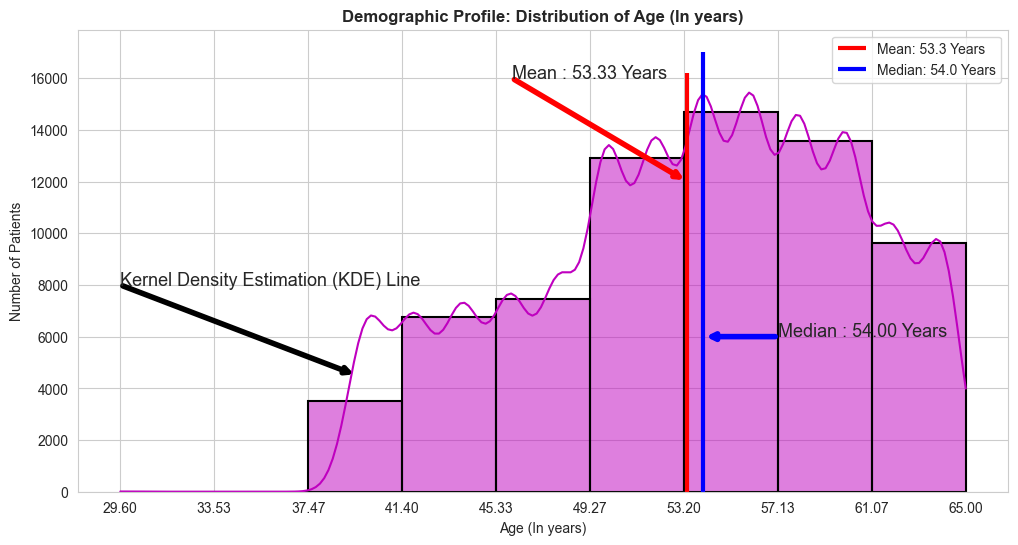

In [23]:
# Distribution of 1st Numerical Feature: Age [In Years]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
histogram_plot (
                dataframe=df, 
                feature= "age", 
                title = "Demographic Profile: Distribution of Age (In years)",
                xlabel= "Age (In years)",
                ylabel= "Number of Patients",
                kde_xy= (39.5, 4500),
                kde_xytext= (29.6, 8000),
                mean_xy= (53.32,12000),
                mean_xytext= (46,16000),
                median_xy= (54,6000),
                median_xytext= (57.14,6000),
                display_text= "Years"
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 1st Numerical Feature (Age) [Univariate Analysis]
log_progress ("(3.1.1.2) 1st Numerical Feature [Univariate Analysis] - Distribution of Age (In Years)", "INFO")


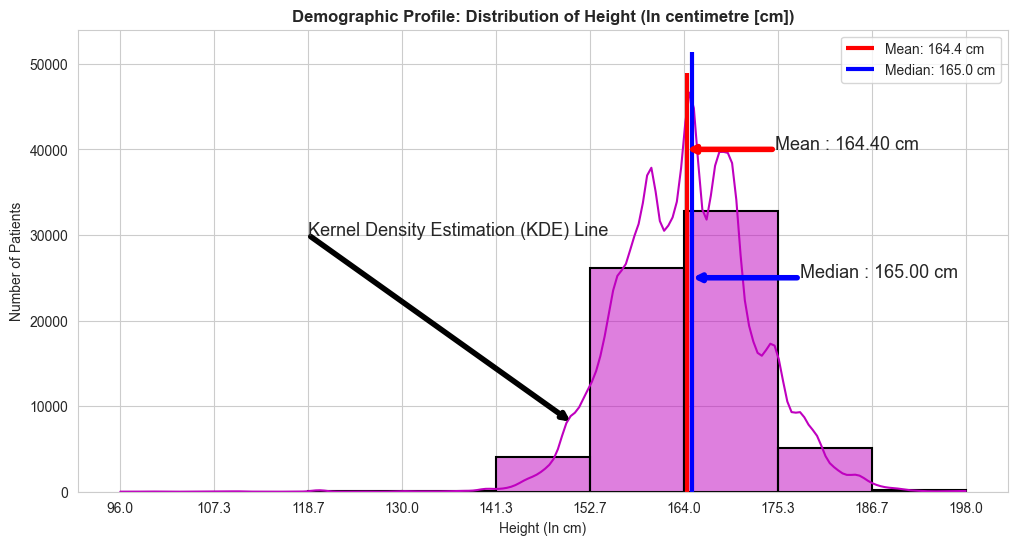

In [24]:
# Distribution of 2nd Numerical Feature: Height (In centimetre [cm])
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# To visualize height (in cm) for better understanding
df["height_in_cm"] = df.height * 100

histogram_plot (
                dataframe=df, 
                feature= "height_in_cm", 
                title = "Demographic Profile: Distribution of Height (In centimetre [cm])",
                xlabel= "Height (In cm)",
                ylabel= "Number of Patients",
                kde_xy= (150.6, 8000),
                kde_xytext= (118.7, 30000),
                mean_xy= (164,40000),
                mean_xytext= (175,40000),
                median_xy= (164.7,25000),
                median_xytext= (178,25000),
                display_text= "cm"
)

# Drop the column (After visualization)
df.drop(columns= "height_in_cm", inplace= True)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 2nd Numerical Feature (Height) [Univariate Analysis]
log_progress ("(3.1.1.3) 2nd Numerical Feature [Univariate Analysis] - Distribution of Height (In centimetre [cm])", "INFO")


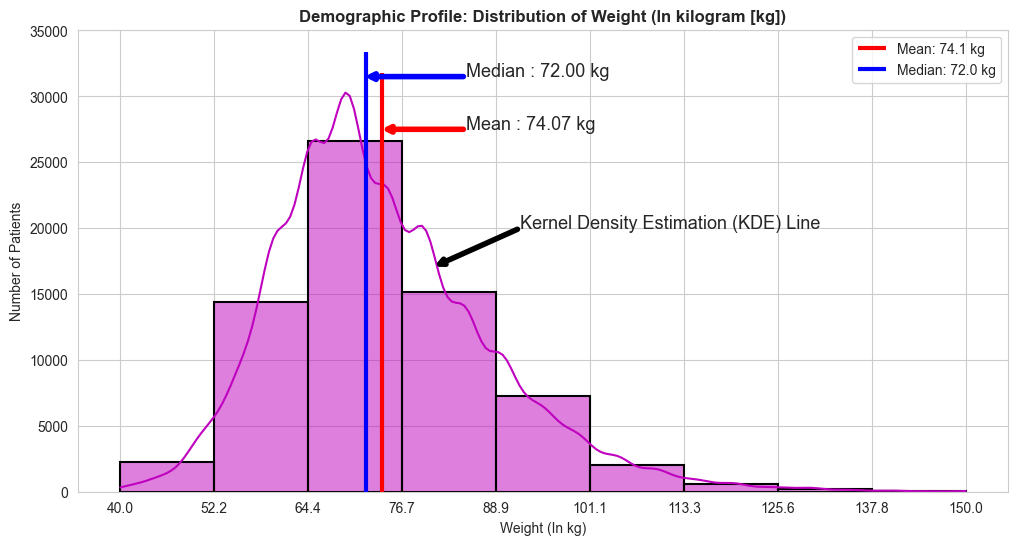

In [25]:
# Distribution of 3rd Numerical Feature: Weight (In kilogram [kg])
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
histogram_plot (
                dataframe=df, 
                feature= "weight", 
                title = "Demographic Profile: Distribution of Weight (In kilogram [kg])",
                xlabel= "Weight (In kg)",
                ylabel= "Number of Patients",
                kde_xy= (80.5, 17000),
                kde_xytext= (92, 20000),
                mean_xy= (73.6,27500),
                mean_xytext= (85,27500),
                median_xy= (71.4,31500),
                median_xytext= (85,31500),
                display_text= "kg"
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 3rd Numerical Feature (Weight) [Univariate Analysis]
log_progress ("(3.1.1.4) 3rd Numerical Feature [Univariate Analysis] - Distribution of Weight (In kilogram [kg])", "INFO")


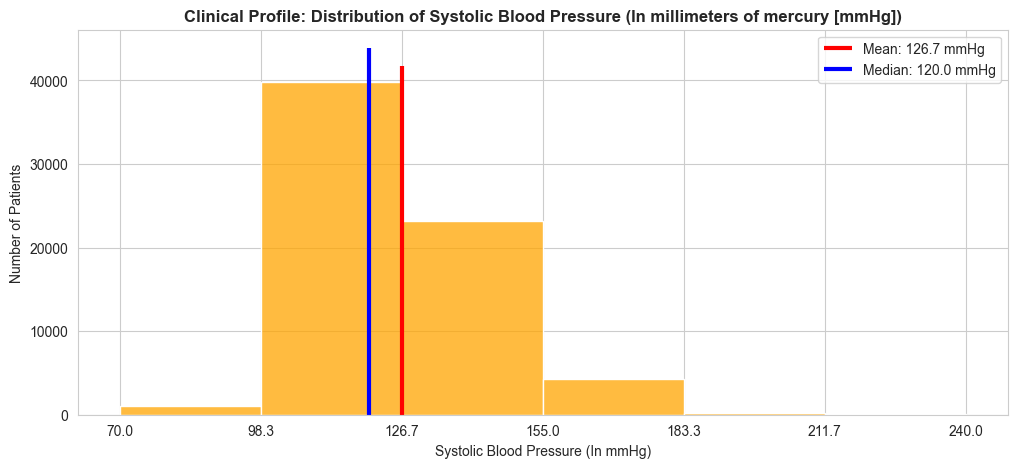

In [26]:
# Distribution of 4th Numerical Feature: Systolic Blood Pressure (In millimeters of mercury [mmHg])
# Highly concentrated cluster - KDE line would explode (So designing a custom plot)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(12,5))
sns.histplot(data= df, x= "ap_hi", bins= np.linspace(df.ap_hi.min(), df.ap_hi.max(), 7), color= "orange")
plt.vlines(x = df["ap_hi"].mean(), ymin = plt.gca().get_ylim()[0], ymax = plt.gca().get_ylim()[1], 
           colors = "red", label = f"Mean: {np.round(df.ap_hi.mean(), 1)} mmHg", linewidth= 3)
plt.vlines(x = df["ap_hi"].median(), ymin = plt.gca().get_ylim()[0], ymax = plt.gca().get_ylim()[1], 
           colors = "blue", label = f"Median: {np.round(df.ap_hi.median(), 1)} mmHg", linewidth= 3)
plt.title("Clinical Profile: Distribution of Systolic Blood Pressure (In millimeters of mercury [mmHg])", fontweight="bold")
plt.xlabel("Systolic Blood Pressure (In mmHg)")
plt.ylabel("Number of Patients")
plt.xticks(np.linspace(df.ap_hi.min(), df.ap_hi.max(), 7))
plt.legend()
plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 4th Numerical Feature (Systolic Blood Pressure) [Univariate Analysis]
log_progress ("(3.1.1.5) 4th Numerical Feature [Univariate Analysis] - Distribution of Systolic Blood Pressure (In [mmHg])", "INFO")


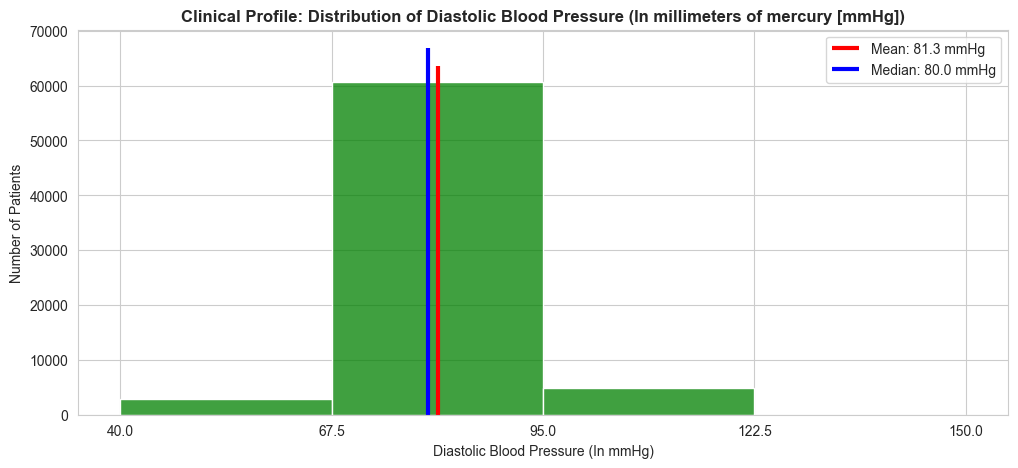

In [27]:
# Distribution of 5th Numerical Feature: Diastolic Blood Pressure (In millimeters of mercury [mmHg])
# Highly concentrated cluster - KDE line would explode (So designing a custom plot)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(12,5))
sns.histplot(data= df, x= "ap_lo", bins= np.linspace(df.ap_lo.min(), df.ap_lo.max(), 5), color= "green")
plt.vlines(x = df["ap_lo"].mean(), ymin = plt.gca().get_ylim()[0], ymax = plt.gca().get_ylim()[1], 
           colors = "red", label = f"Mean: {np.round(df.ap_lo.mean(), 1)} mmHg", linewidth= 3)
plt.vlines(x = df["ap_lo"].median(), ymin = plt.gca().get_ylim()[0], ymax = plt.gca().get_ylim()[1], 
           colors = "blue", label = f"Median: {np.round(df.ap_lo.median(), 1)} mmHg", linewidth= 3)
plt.title("Clinical Profile: Distribution of Diastolic Blood Pressure (In millimeters of mercury [mmHg])", fontweight="bold")
plt.xlabel("Diastolic Blood Pressure (In mmHg)")
plt.ylabel("Number of Patients")
plt.xticks(np.linspace(df.ap_lo.min(), df.ap_lo.max(), 5))
plt.legend()
plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 5th Numerical Feature (Diastolic Blood Pressure) [Univariate Analysis]
log_progress ("(3.1.1.6) 5th Numerical Feature [Univariate Analysis] - Distribution of Diastolic Blood Pressure (In [mmHg])", "INFO")


<span style="font-size:20px; font-weight:bold">3.1.2 Visualise Categorical Features</span>

Visualise the distribution of categorical features to understand category frequencies and identify any potential imbalances or dominant groups.

In [28]:
# Let's view the categorical features [Before plotting them, to understand the data distribution across various categories]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df.select_dtypes(include=["category"]).head(5)


,gender,cholesterol,gluc,smoke,alco,active,cardio
0,1,0,0,0,0,1,0
1,0,2,0,0,0,1,1
2,0,2,0,0,0,0,1
3,1,0,0,0,0,1,1
4,0,0,0,0,0,0,0


In [29]:
# Custom Horizontal Bar Plot Reusable Function
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def horizontal_bar_plot(value_count_series, title, xlabel, ylabel, color, xticks_range):
    """
    Docstring:
              Plots a highly customizable Horizontal Bar Plot for Univariate Analysis.
              Analyzing the distribution of a categorical variable.
    Parameters:
              dataframe : pandas.Series
                          Accepts the Series containing the value count of the categorical feature.
              title : str
                          The main title of the generated plot (Display Title name at the top of the plot)
              xlabel : str
                          The label corresponding to the x-axis (Display the Label name on the x-axis)
              ylabel : str
                          The label corresponding to the y-axis (Display the Label name on the y-axis)
              color : str
                          The color of the bars in the barchart.
              xticks_range : range
                          Controls the range of the x-axis
    Returns:
              None : 
                     The Function displays a configured plot directly in the notebook.
    """
    # Plotting a Horizontal Bar Chart --- Analyzing Frequency Distribution of Categorical Features
    # --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting Frequency Distribution

    plt.figure (figsize=(12,6))
    container_bars = plt.barh(
                                value_count_series.index, 
                                value_count_series.values,
                                height = 0.8,
                                zorder = 0,
                                color = f"{color}"
    )
    plt.title (f"{title}", fontweight="bold")
    plt.xlabel(f"{xlabel}")
    plt.xticks(xticks_range)
    plt.ylabel(f"{ylabel}")
    plt.ticklabel_format(style= "plain", axis="x")

    # Customization : Labelling for Bars
    plt.bar_label(container= container_bars, padding= 5, fontsize= 15)
    plt.tight_layout()

    # Plotting the Bar Chart
    return plt.show()
    
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Custom Horizontal Bar Chart Reusable Function [Categorical Features]
log_progress ("(3.1.2.1) Custom Bar Chart Reusable Function - Analyzing Categorical Features Distribution.", "INFO")


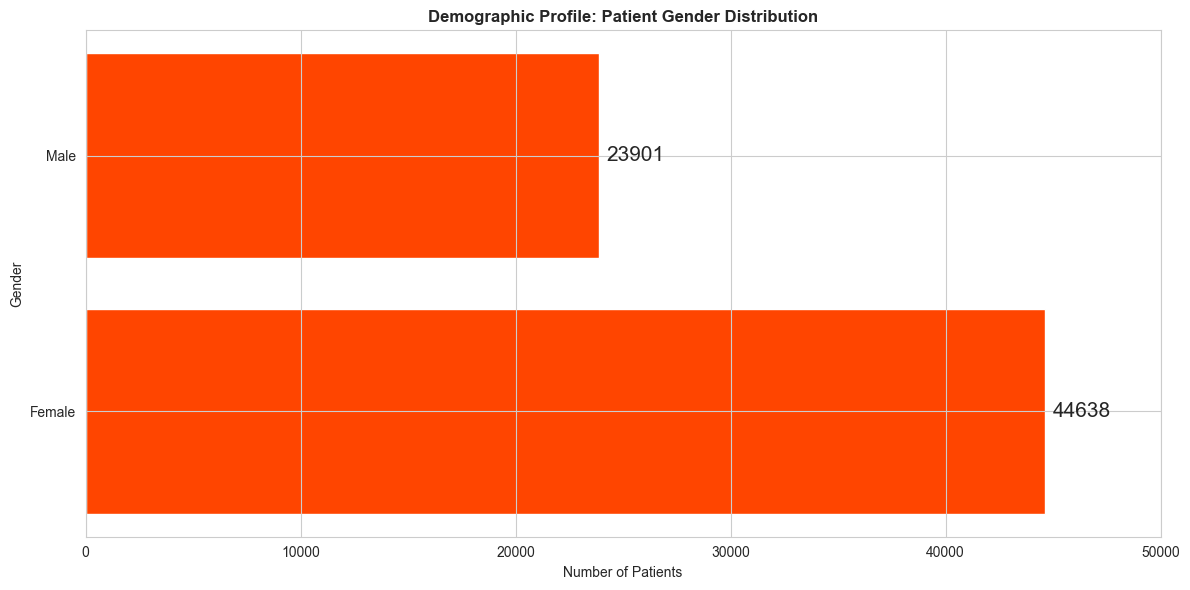

In [30]:
# Distribution of 1st Categorical Feature (Gender)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Assumption: {0 is female, 1 is male}
value_count_series = df["gender"].value_counts()
value_count_series.rename(index={0: "Female", 1: "Male"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series,
                     title = "Demographic Profile: Patient Gender Distribution",
                     xlabel= "Number of Patients",
                     ylabel= "Gender",
                     color= "orangered",
                     xticks_range= range(0,60000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 1st Categorical Feature (Gender)
log_progress ("(3.1.2.2) 1st Categorical Feature - Demographic Profile: Patient Gender Distribution", "INFO")


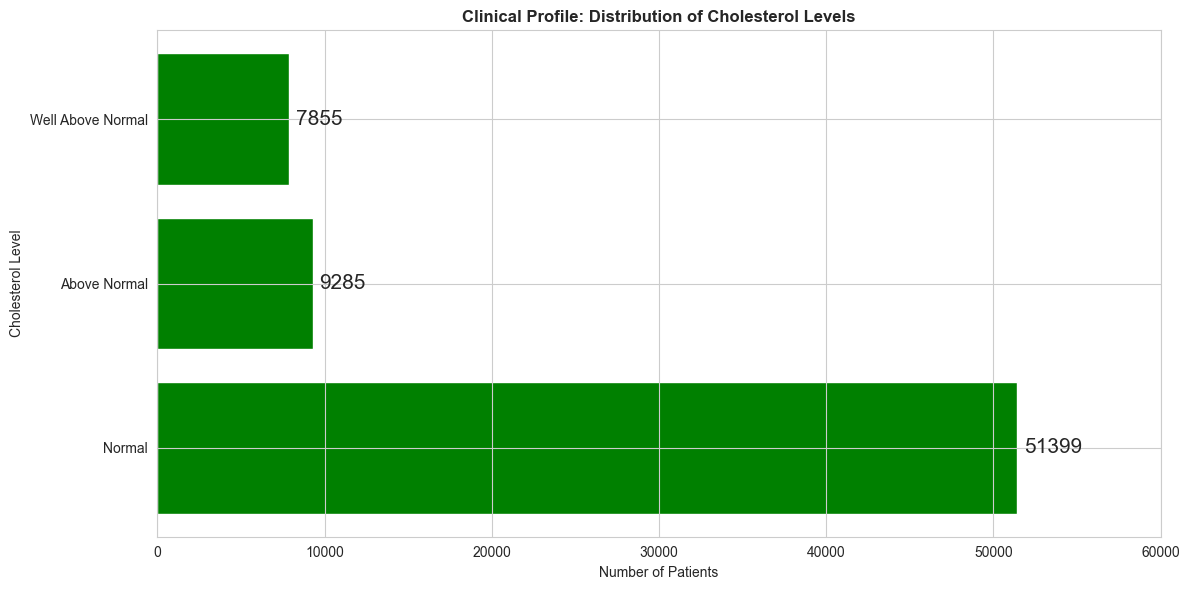

In [31]:
# Distribution of 2nd Categorical Feature (Cholesterol)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Assumption: (0: normal, 1: above normal, 2: well above normal)
value_count_series = df["cholesterol"].value_counts()
value_count_series.rename(index={0: "Normal", 1: "Above Normal", 2: "Well Above Normal"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series,
                     title = "Clinical Profile: Distribution of Cholesterol Levels",
                     xlabel= "Number of Patients",
                     ylabel= "Cholesterol Level",
                     color= "green",
                     xticks_range= range(0,70000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 2nd Categorical Feature (Cholesterol)
log_progress ("(3.1.2.3) 2nd Categorical Feature - Clinical Profile: Distribution of Cholesterol Levels", "INFO")


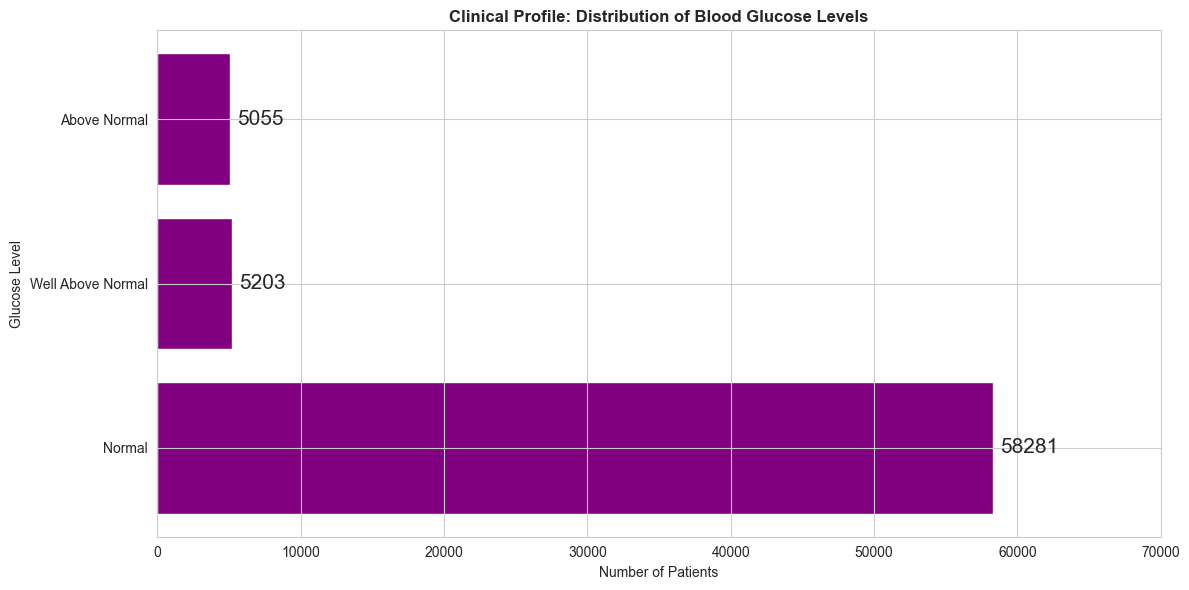

In [32]:
# Distribution of 3rd Categorical Feature (Glucose)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Assumption: (0: normal, 1: above normal, 2: well above normal)
value_count_series = df["gluc"].value_counts()
value_count_series.rename(index={0: "Normal", 1: "Above Normal", 2: "Well Above Normal"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series, 
                     title = "Clinical Profile: Distribution of Blood Glucose Levels",
                     xlabel= "Number of Patients",
                     ylabel= "Glucose Level",
                     color= "purple",
                     xticks_range= range(0,80000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 3rd Categorical Feature (Glucose)
log_progress ("(3.1.2.4) 3rd Categorical Feature - Clinical Profile: Distribution of Blood Glucose Levels", "INFO")


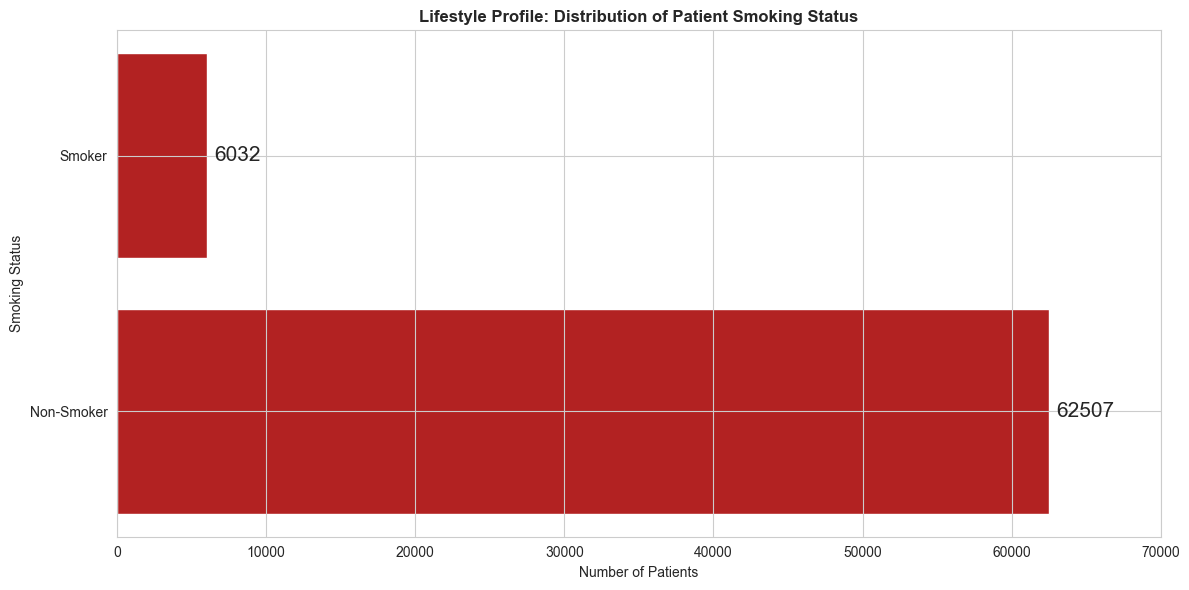

In [33]:
# Distribution of 4th Categorical Feature (Smoking Status)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Data Dictionary: (0: No, 1: Yes)
value_count_series = df["smoke"].value_counts()
value_count_series.rename(index={0: "Non-Smoker", 1: "Smoker"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series, 
                     title = "Lifestyle Profile: Distribution of Patient Smoking Status",
                     xlabel= "Number of Patients",
                     ylabel= "Smoking Status",
                     color= "firebrick",
                     xticks_range= range(0,80000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 4th Categorical Feature (Smoking Status)
log_progress ("(3.1.2.5) 4th Categorical Feature - Lifestyle Profile: Distribution of Patient Smoking Status", "INFO")


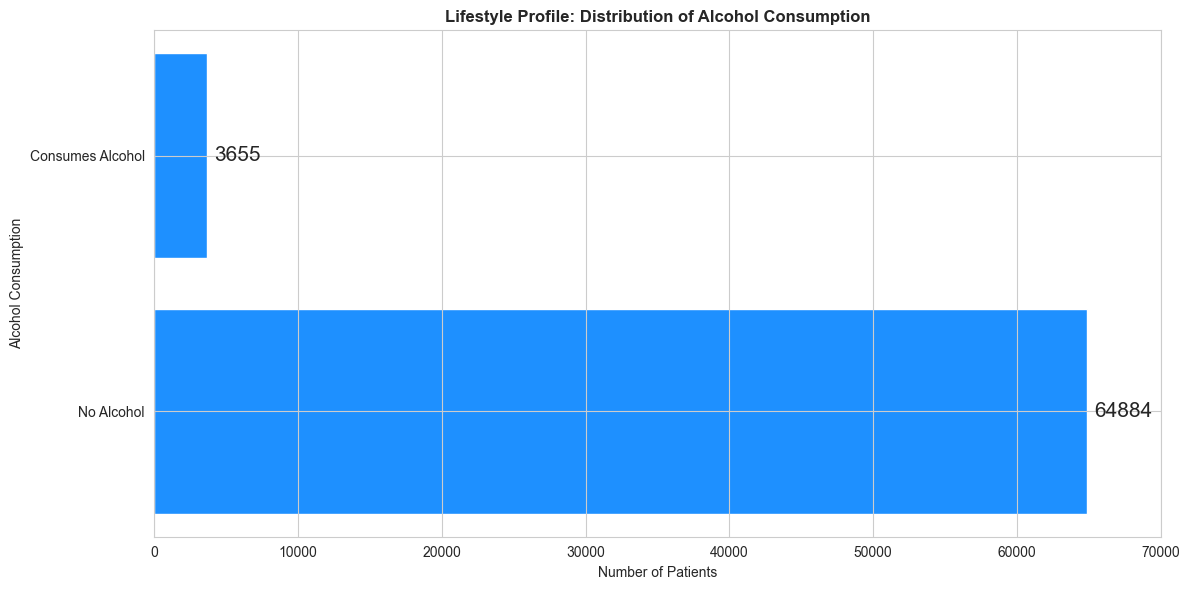

In [34]:
# Distribution of 5th Categorical Feature (Alcohol Consumption).
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Data Dictionary: (0: No, 1: Yes)
value_count_series = df["alco"].value_counts()
value_count_series.rename(index={0: "No Alcohol", 1: "Consumes Alcohol"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series,
                     title = "Lifestyle Profile: Distribution of Alcohol Consumption",
                     xlabel= "Number of Patients",
                     ylabel= "Alcohol Consumption",
                     color= "dodgerblue",
                     xticks_range= range(0,80000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 5th Categorical Feature (Alcohol Intake Status)
log_progress ("(3.1.2.6) 5th Categorical Feature - Lifestyle Profile: Distribution of Alcohol Consumption", "INFO")


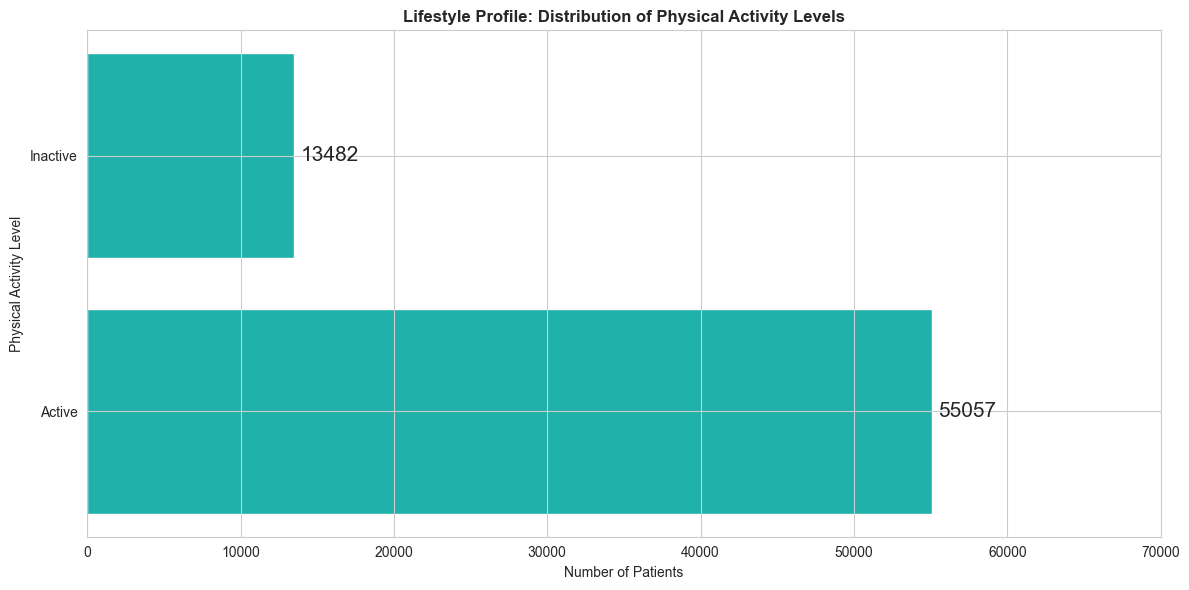

In [35]:
# Distribution of 6th Categorical Feature (Physical Activity Level).
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Data Dictionary: (0: No, 1: Yes)
value_count_series = df["active"].value_counts()
value_count_series.rename(index={0: "Inactive", 1: "Active"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series,
                     title = "Lifestyle Profile: Distribution of Physical Activity Levels",
                     xlabel= "Number of Patients",
                     ylabel= "Physical Activity Level",
                     color= "lightseagreen",
                     xticks_range= range(0,80000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of 6th Categorical Feature (Physical Activity Status)
log_progress ("(3.1.2.7) 6th Categorical Feature - Lifestyle Profile: Distribution of Physical Activity Levels", "INFO")


<span style="font-size:20px; font-weight:bold">3.1.3 Check Target Class Distribution</span>

Examine the distribution of the target variable to assess the balance between the CVD and non-CVD classes.

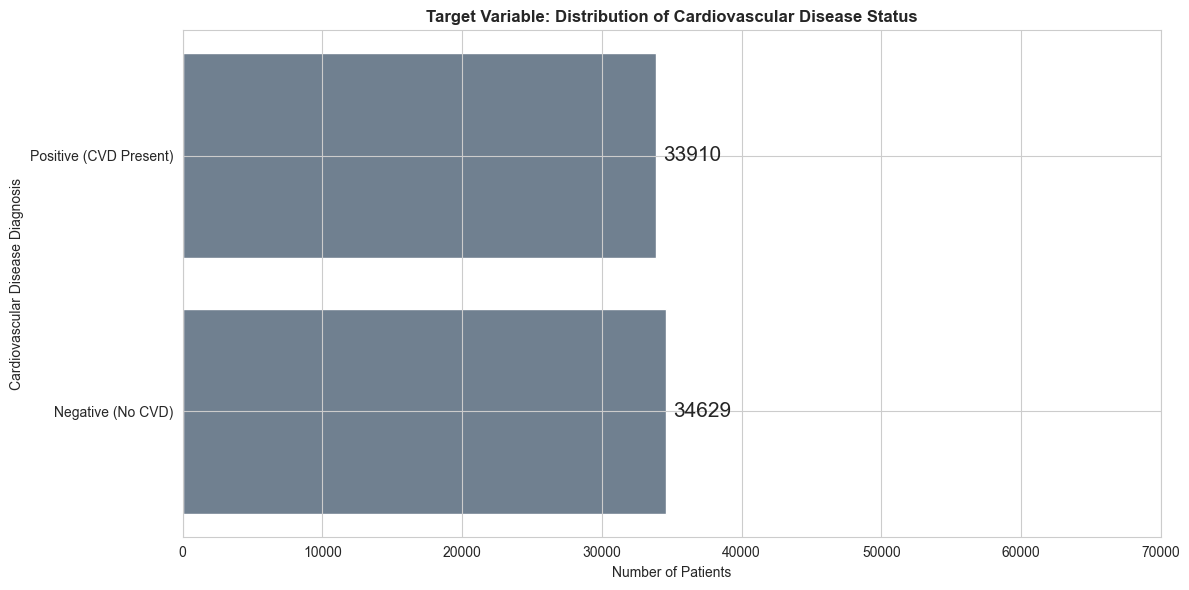

In [36]:
# Class distribution of positive and negative classes [Primary Outcome / Target Variable]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Data Dictionary: (0: No, 1: Yes)
value_count_series = df["cardio"].value_counts()
value_count_series.rename(index={0: "Negative (No CVD)", 1: "Positive (CVD Present)"}, inplace= True)

# Plotting the Horizontal Bar Chart
horizontal_bar_plot (
                     value_count_series= value_count_series,
                     title = "Target Variable: Distribution of Cardiovascular Disease Status",
                     xlabel= "Number of Patients",
                     ylabel= "Cardiovascular Disease Diagnosis",
                     color= "slategray",
                     xticks_range= range(0,80000,10000)
)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Distribution of Target Feature (Cardiovascular Disease Status)
log_progress ("(3.1.3.1) Target Feature - Target Variable: Distribution of Cardiovascular Disease Status", "INFO")


<span style="font-size:22px; font-weight:bold">3.2 Correlation Analysis</span>

Analyse the relationships between numerical features to identify correlations, potential dependencies, and multicollinearity. Use a correlation matrix to visualise and interpret these relationships.

<span style="font-size:20px; font-weight:bold">3.2.1 Visualise Correlations Among Numerical Features</span>

Visualise the correlation matrix of numerical features to identify the strength and direction of relationships between variables and detect potential multicollinearity.

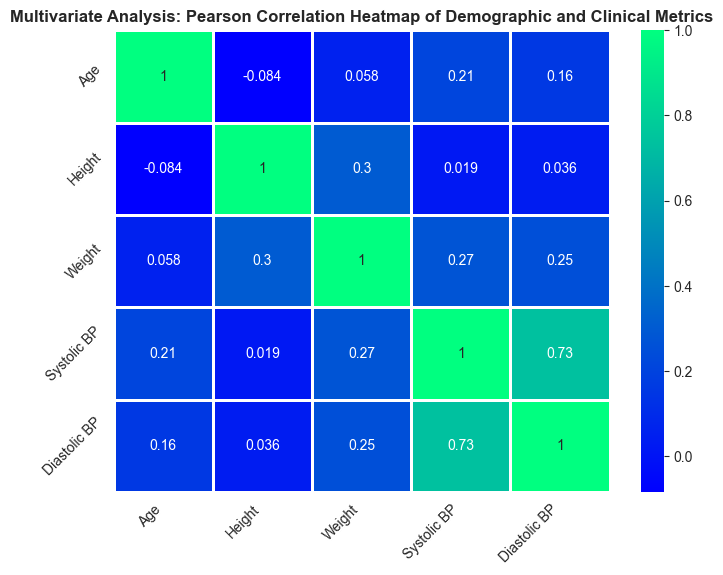

In [37]:
# Plot Heatmap of the correlation matrix [Correlation among numerical features]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
correlation_matrix = df.select_dtypes(["float64", "int64"]).corr()
naming_dictionary  = {"age" : "Age", "height" : "Height", "weight" : "Weight", "ap_hi" : "Systolic BP", "ap_lo" : "Diastolic BP"}
correlation_matrix.rename(index= naming_dictionary, columns= naming_dictionary, inplace= True)

plt.figure(figsize= (8,6))
sns.heatmap(data= correlation_matrix, cmap= "winter", annot= True, linecolor= "white", linewidths= 0.8)
plt.title("Multivariate Analysis: Pearson Correlation Heatmap of Demographic and Clinical Metrics", fontweight="bold")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=45, ha="right")
plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Correlation Analysis among Numerical Features
log_progress ("(3.2.1.1) Correlation Analysis [Numerical Features]: Pearson Correlation Heatmap", "INFO")


<span style="font-size:22px; font-weight:bold">3.3 Bivariate Analysis</span>

Analyse relationships between pairs of variables to identify patterns and understand how individual features relate to CVD risk.

<span style="font-size:20px; font-weight:bold">3.3.1 Analyse Categorical Features</span>

Analyse the relationship between each categorical feature and CVD risk by comparing the proportion of positive cases across categories to identify meaningful differences and informative features.

In [38]:
# Bivariate Analysis: Target Variable Distribution Across Categorical Features
# Write a function to analyse the target variable likelihood for categorical features
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def calculate_proportions(dataframe: pd.DataFrame, categorical_features : list):
    # Renaming Columns
    renaming_columns = {
                        "gender" : "Gender",
                        "cholesterol" : "Cholesterol Level", 
                        "gluc" : "Glucose Level", 
                        "smoke" : "Smoking Status", 
                        "alco" : "Alcohol Consumption", 
                        "active" : "Physical Activity"
                       } 
    # Performance Optimization: Dictionaries
    index_dictionary_map = {
                            "gender": {0: "Female", 1: "Male"},
                            "cholesterol": {0: "Normal", 1: "Above Normal", 2: "Well Above Normal"},
                            "gluc": {0: "Normal", 1: "Above Normal", 2: "Well Above Normal"},
                            "smoke": {0: "Non-Smoker", 1: "Smoker"},
                            "alco": {0: "No Alcohol", 1: "Consumes Alcohol"},
                            "active": {0: "Inactive", 1: "Active"}
                            }
    print("-" * 80); print(f"{color.BOLD}Bivariate Analysis: Target Variable Distribution Across Categorical Features{color.END}"); print("-" * 80)
    
    # Iterate through the list of categorical features [To collect appropiate proportions & likelihood]
    for feature_name in categorical_features:
        # Excluding the Target Variable (`cardio`)
        if feature_name == "cardio": continue
            
        # Using crosstab and leveraging `normalize` we will calculate proportions
        proportion_df = np.round(pd.crosstab(index=dataframe[f"{feature_name}"], columns=dataframe["cardio"], normalize= "index") * 100, 2).copy()
        
        # Conditional Renaming of Indexes [Renaming Cardiovascular Disease Columns & Renaming Indexes]
        if feature_name in  index_dictionary_map:
            proportion_df.rename(
                                 index= index_dictionary_map[feature_name], 
                                 columns= {0: "Negative (No CVD)", 1: "Positive (CVD Present)"},  
                                 inplace= True
                                )
        # Final Display
        print(f"\n{color.BOLD}Likelihood of Cardiovascular Disease based on '{renaming_columns[feature_name]}':-{color.END}\n")
        proportion_df.index.name, proportion_df.columns.name = None, None
        display(proportion_df); print(f"{color.BOLD}-{color.END}" * 80)
        
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Returns the Target Variable Distribution Across Categorical Features [Bivariate Analysis]
calculate_proportions(dataframe=df, categorical_features= df.select_dtypes(["category"]).columns.tolist())

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Bivariate Analysis among Categorical Features
log_progress ("(3.3.1.1) Bivariate Analysis: Target Variable Distribution Across Categorical Features", "INFO")


--------------------------------------------------------------------------------
Bivariate Analysis: Target Variable Distribution Across Categorical Features
--------------------------------------------------------------------------------

Likelihood of Cardiovascular Disease based on 'Gender':-



,Negative (No CVD),Positive (CVD Present)
Female,50.78,49.22
Male,50.05,49.95


--------------------------------------------------------------------------------

Likelihood of Cardiovascular Disease based on 'Cholesterol Level':-



,Negative (No CVD),Positive (CVD Present)
Normal,56.46,43.54
Above Normal,40.34,59.66
Well Above Normal,23.74,76.26


--------------------------------------------------------------------------------

Likelihood of Cardiovascular Disease based on 'Glucose Level':-



...

--------------------------------------------------------------------------------

Likelihood of Cardiovascular Disease based on 'Alcohol Consumption':-



,Negative (No CVD),Positive (CVD Present)
No Alcohol,50.43,49.57
Consumes Alcohol,52.28,47.72


--------------------------------------------------------------------------------

Likelihood of Cardiovascular Disease based on 'Physical Activity':-



,Negative (No CVD),Positive (CVD Present)
Inactive,46.71,53.29
Active,51.46,48.54


--------------------------------------------------------------------------------


<span style="font-size:20px; font-weight:bold">3.3.2 Explore Numerical Features Against the Target</span>

Analyse the relationships between numerical features and the target variable to identify trends, patterns, and potential associations with CVD risk.

1) The Relationship between 'Age' and 'Cardiovascular Disease':-



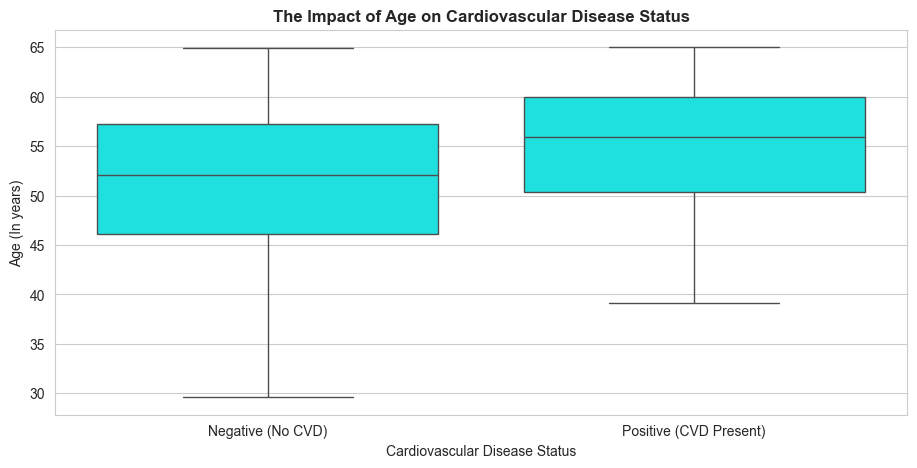

------------------------------------------------------------------------------------------------------------------------------------------------------
2) The Relationship between 'Height' and 'Cardiovascular Disease':-



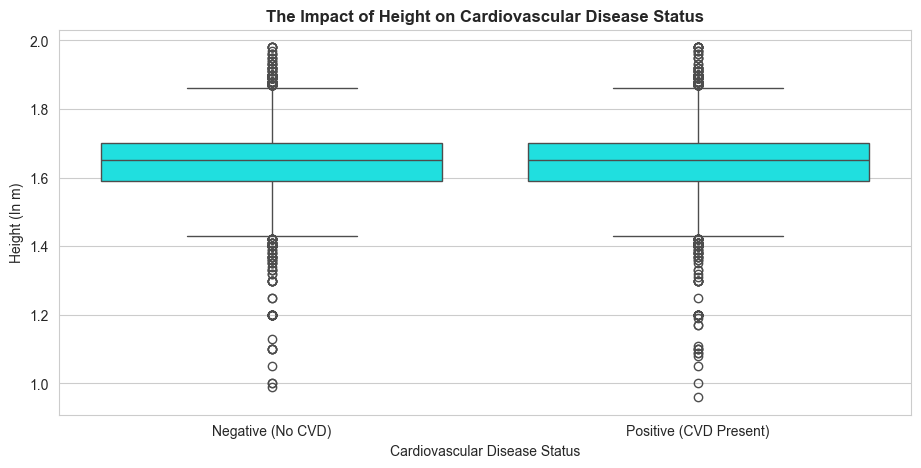

------------------------------------------------------------------------------------------------------------------------------------------------------
3) The Relationship between 'Weight' and 'Cardiovascular Disease':-



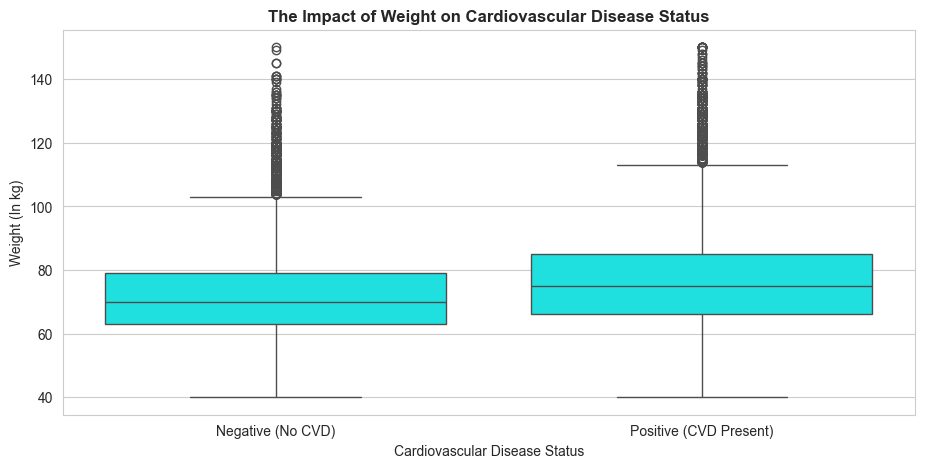

------------------------------------------------------------------------------------------------------------------------------------------------------
4) The Relationship between 'Systolic BP' and 'Cardiovascular Disease':-



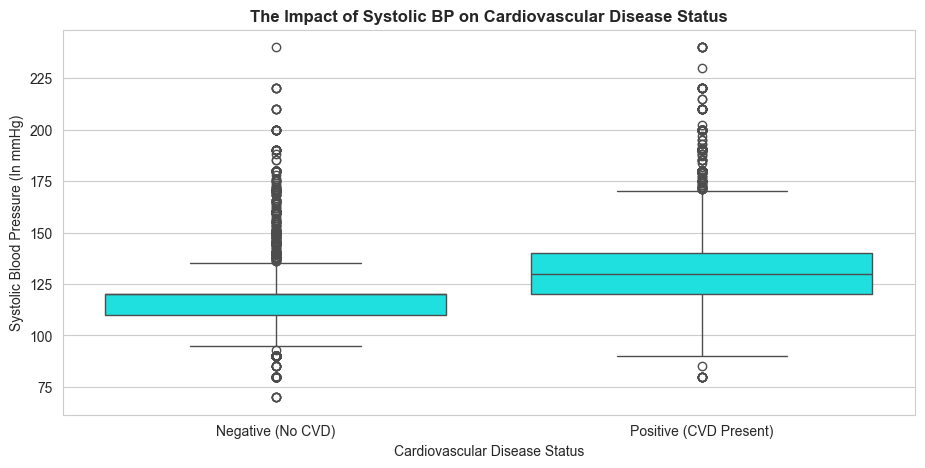

------------------------------------------------------------------------------------------------------------------------------------------------------
5) The Relationship between 'Diastolic BP' and 'Cardiovascular Disease':-



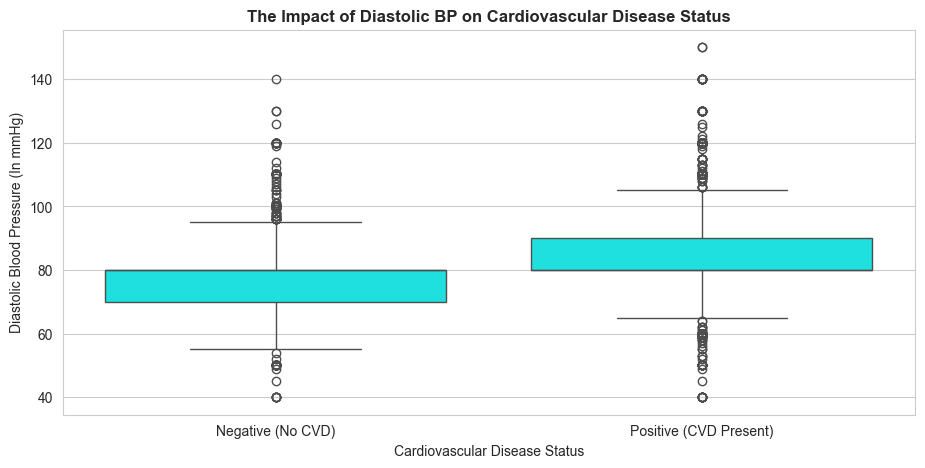

------------------------------------------------------------------------------------------------------------------------------------------------------


In [39]:
# Plot distribution for each numerical column with target variable
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
numerical_naming_dictionary  = {
                                "age" : "Age (In years)", 
                                "height" : "Height (In m)", 
                                "weight" : "Weight (In kg)", 
                                "ap_hi" : "Systolic Blood Pressure (In mmHg)", 
                                "ap_lo" : "Diastolic Blood Pressure (In mmHg)"
                                }
# For Readability and Better Visualization
df["cardiovascular"] = df["cardio"].map({0: "Negative (No CVD)", 1: "Positive (CVD Present)"}).astype("category")

for index, numerical in enumerate(df.select_dtypes(["int64", "float64"]).columns.tolist()):   
    print (color.BOLD + f"{index + 1}) The Relationship between '{naming_dictionary[numerical]}' and 'Cardiovascular Disease':-\n" + color.END)
    
    plt.figure(figsize= (11,5))
    sns.boxplot(data = df, x= "cardiovascular", y= numerical, color="aqua")
    plt.title(f"The Impact of {naming_dictionary[numerical]} on Cardiovascular Disease Status", fontweight="bold")
    plt.xlabel("Cardiovascular Disease Status")
    plt.ylabel(f"{numerical_naming_dictionary[numerical]}")
    plt.show(); print("-" * 150)

# Drop the Redundant Column which served its purpose of visualization
df.drop(columns= "cardiovascular", inplace= True)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Bivariate Analysis among Numerical Features
log_progress ("(3.3.2.1) Bivariate Analysis: Target Variable Distribution Across Numerical Features\n", "INFO")


---

<span style="font-size:25px; font-weight:bold">4.Training and Test Set Preparation</span>


<span style="font-size:22px; font-weight:bold">4.1 Data Splitting</span>

Split the dataset into training and test sets to develop the models on one portion of the data and evaluate their performance on unseen observations.

<span style="font-size:20px; font-weight:bold">4.1.1 Define Features and Target</span>

Separate the dataset into feature variables used for prediction and the target variable representing the CVD outcome.

In [40]:
log_progress ("============================= Step 4 : Train-Test Split for Machine Learning Models =============================", "INFO") 

In [41]:
# Put all the feature variables in X and target in y
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Defining / Creation of Predictors (X) and Target (y)
X = df.drop(columns= ["cardio"]).copy()
y = df["cardio"].copy()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Data Separation into Predictors and Target
log_progress("(4.1.1) Data Separation: Successfully isolated predictor features (X) and target variable (y)", "INFO")


<span style="font-size:20px; font-weight:bold">4.1.2 Split the Data into Training and Test Sets</span>

Split the data into training and test sets using a 70:30 ratio, reset their indices, and verify the resulting dimensions.

In [42]:
#  Split the data into 70% train data and 30% test data
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
try:
    # Split Data -- Into Training and Testing Sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7, random_state= 42)

except Exception as e:
    print(f"An error was encountered while 'Splitting the Data': {e}")
    log_progress(f"(4.1.2) An error was encountered while 'Splitting the Data': {e}")

else:
    # Reset index for all train and test sets
    X_train, X_test = X_train.reset_index(drop= True), X_test.reset_index(drop= True)
    y_train, y_test = y_train.reset_index(drop= True), y_test.reset_index(drop= True)

    # Displaying and Logging: Validation logs to ensure split is correct
    print("-" * 100); print(f"{color.BOLD}Data Splitting: Training abd Testing Sets Allocation [70:30][Training:Testing][Shape Validation]{color.END}"); print("-" * 100)
    print(f"Data Split [Training and Testing Sets Shape] - Training Set: {X_train.shape}, Testing Set: {X_test.shape}")
    print(f"Data Split Proportions [Manual Verification] - Training Proportion: {np.round(X_train.shape[0]/df.shape[0] * 100, 2)}%, Testing Proportion: {np.round(X_test.shape[0]/df.shape[0] * 100, 2)}%"); print("-" * 100)
    log_progress(f"(4.1.2) Data Split [70:30][Training:Testing] - Training: {X_train.shape}, Testing: {X_test.shape}\n")
  

----------------------------------------------------------------------------------------------------
Data Splitting: Training abd Testing Sets Allocation [70:30][Training:Testing][Shape Validation]
----------------------------------------------------------------------------------------------------
Data Split [Training and Testing Sets Shape] - Training Set: (47977, 11), Testing Set: (20562, 11)
Data Split Proportions [Manual Verification] - Training Proportion: 70.0%, Testing Proportion: 30.0%
----------------------------------------------------------------------------------------------------


---

<span style="font-size:25px; font-weight:bold">5. Feature Engineering</span>

<span style="font-size:22px; font-weight:bold">5.1 Feature Engineering and Correlation Analysis</span>

Create a meaningful new feature from the existing variables and assess its relationship with other numerical features to determine whether it provides additional useful information.

In [43]:
log_progress ("================================ Step 5 : Feature Engineering and Feature Scaling ===============================", "INFO") 

<span style="font-size:20px; font-weight:bold">5.1.1 Create BMI (Body Mass Index) Feature</span>

Create a BMI (Body Mass Index) feature using the patient's height and weight to provide an additional health indicator for analysing cardiovascular risk.

In [44]:
# Feature Engineering: Body Mass Index 'BMI' -----> Weight(kg) / [Height(m)**2]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Rule of Thumb: Apply feature engineering to both 'X_train' & 'X_test'
for datasets, names, placeholders in zip([X_train, X_test], ["X_train", "X_test"], ["(5.1.1.1)", "(5.1.1.2)"]):

    # Feature Engineering: Body Mass Index (BMI)
    datasets["BMI"] = datasets["weight"] / (datasets["height"] ** 2)
    
    # Drop 'Height' and 'Weight' -- Since BMI captures it
    datasets.drop(columns=["weight", "height"], inplace= True)
    
    # Display and Logging
    log_progress(f"{placeholders} Feature Engineering: Body Mass Index (BMI) [{names}], Dropped 'height' and 'weight' features from [{names}]")

print(f"{color.BOLD}Feature Engineering:{color.END} Body Mass Index (BMI) Successful.")


Feature Engineering: Body Mass Index (BMI) Successful.


**Note:** Feel free to engineer more features if you wish to.

<span style="font-size:20px; font-weight:bold">5.1.2 Reassess Feature Correlations</span>

Reassess the correlations across all numerical features after adding BMI to identify strong relationships and address potential multicollinearity before modelling.

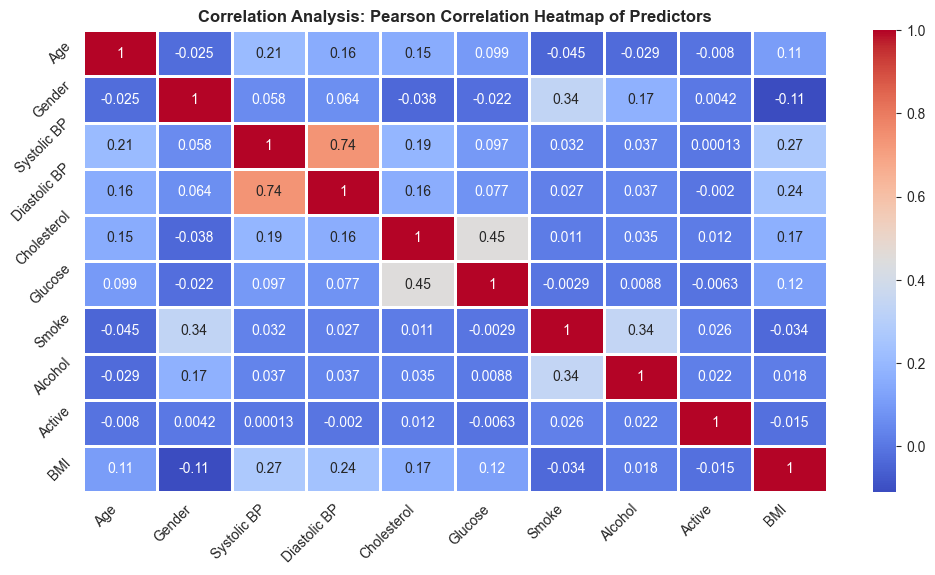

In [45]:
# Correlation Analysis: Visualization performed using a Heatmap
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
correlation_matrix = X_train.corr()
naming_dictionary  = {
                      "age" : "Age", 
                      "gender" : "Gender", 
                      "ap_hi" : "Systolic BP", 
                      "ap_lo" : "Diastolic BP", 
                      "cholesterol" : "Cholesterol", 
                      "gluc" : "Glucose", 
                      "smoke" : "Smoke", 
                      "alco" : "Alcohol", 
                      "active" : "Active", 
                      "BMI" : "BMI"
                     }
correlation_matrix.rename(index= naming_dictionary, columns= naming_dictionary, inplace= True)

plt.figure(figsize= (12,6))
sns.heatmap(data= correlation_matrix, cmap= "coolwarm", annot= True, linecolor= "white", linewidths= 0.8)
plt.title("Correlation Analysis: Pearson Correlation Heatmap of Predictors", fontweight="bold")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=45, ha="right")
plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Correlation Analysis: Pearson Correlation Heatmap of Predictors
log_progress("(5.1.2.1) Correlation Analysis: Pearson Correlation Heatmap of Predictors", "INFO")


In [46]:
# Did you find any highly correlated features? What steps should you take
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Steps taken to handle Multicollinearity:-
# 1) If "weight" wasn't dropped along with "height" in the earlier step, we would have seen strong positive correlation between "weight" and "BMI"
# 2) Converting 'Systolic and Diastolic BP' into a single metric 'Mean Arterial Pressure (MAP)' [finds the average arterial blood pressure during a single cardiac cycle]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Rule of Thumb: Apply feature engineering to both 'X_train' & 'X_test'
for datasets, names, placeholders_1, placeholders_2 in zip([X_train, X_test], ["X_train", "X_test"], ["(5.1.2.2)", "(5.1.2.4)"], ["(5.1.2.3)", "(5.1.2.5)"]):
    
    # Feature Engineering: Mean Arterial Pressure (MAP) ---> (S.BP + 2 * D.BP) / 3
    datasets["MAP"] = (datasets["ap_hi"] + 2 * datasets["ap_lo"]) / 3
    
    # Drop 'Systolic BP (ap_hi)' and 'Diastolic BP (ap_lo)' -- Since MAP captures it
    datasets.drop(columns=["ap_hi", "ap_lo"], inplace= True)
    
    # Display and Logging
    log_progress(f"{placeholders_1} Feature Engineering: Mean Arterial Pressure (MAP) [{names}]")
    log_progress(f"{placeholders_2} Dropped 'Systolic BP (ap_hi)' and 'Diastolic BP (ap_lo)' features from [{names}]")

print(f"{color.BOLD}Feature Engineering:{color.END} Mean Arterial Pressure (MAP) Successful.")


Feature Engineering: Mean Arterial Pressure (MAP) Successful.


<span style="font-size:22px; font-weight:bold">5.2 Consolidate Categorical Values</span>


<span style="font-size:20px; font-weight:bold">5.2.1 Combine Low-Frequency Categories</span>

Group infrequent or similar categorical values to reduce sparsity and improve feature representation for modelling.

In [47]:
# Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# `cholestrol`: Representing Cholestrol level (Previous Assumption: {0: normal, 1: above normal, 2: well above normal})
# `gluc`: Representing Glucose Level (Previous Assumption: {0: normal, 1: above normal, 2: well above normal})
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Consolidation of Cholestrol Level and Glucose Level into Binary Features: {0: Normal, 1: Above Normal}
for datasets, names, placeholders in zip([X_train, X_test], ["X_train", "X_test"], ["(5.2.1.1)", "(5.2.1.2)"]):
    
    # Feature Engineering: Cholesterol [Converting to Binary] [Explicit DataType defined]
    datasets["cholesterol"] = datasets["cholesterol"].map({0:0, 1:1, 2:1})
    datasets["cholesterol"] = datasets["cholesterol"].astype("category")

    # Feature Engineering: Gluc [Converting to Binary] [Explicit DataType defined]
    datasets["gluc"] = datasets["gluc"].map({0:0, 1:1, 2:1})    
    datasets["gluc"] = datasets["gluc"].astype("category")
    
    # Display and Logging
    log_progress(f"{placeholders} Feature Engineering: Binarized 'cholesterol' and 'gluc' categories for [{names}]")

print(f"{color.BOLD}Feature Engineering:{color.END} Cholesterol Level and Glucose Level updated successfully.")

Feature Engineering: Cholesterol Level and Glucose Level updated successfully.


<span style="font-size:22px; font-weight:bold">5.3 Encode Categorical Variables</span>


<span style="font-size:20px; font-weight:bold">5.3.1 Create Dummy Variables</span>

Convert categorical columns into dummy variables to enable their use in machine learning models.

In [48]:
# Creation of Dummy Variables (For Categorical Features/Predictors)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Identify the columns for creating dummy variables
cols_for_dummy = X_train.select_dtypes(["category"]).columns.tolist()
print(f"{color.BOLD}Features/Predictors for creating dummy variables:{color.END} {cols_for_dummy}")

# Create dummy variables for independent columns on training and testing data
X_train = pd.get_dummies(data= X_train, columns= cols_for_dummy, drop_first= True, dtype= "int64")
X_test  = pd.get_dummies(data= X_test , columns= cols_for_dummy, drop_first= True, dtype= "int64")

# Renaming Columns
column_renaming =  {'gender_1': "gender", "cholesterol_1": "cholesterol", "gluc_1": "glucose", "smoke_1": "smoke", "alco_1" : "alcohol", "active_1": "active"}
X_train.rename(columns= column_renaming, inplace= True)
X_test.rename(columns= column_renaming, inplace= True)

# Display and Logging
print(f"{color.BOLD}Creation of Dummy Variables:{color.END} For Categorical features successful ['X_train', 'X_test']")
print(f"{color.BOLD}Shape Verification:{color.END} {X_train.shape} | {X_test.shape}")
log_progress("(5.3.1.1) Creation of Dummy Variables for Categorical features successful ['X_train', 'X_test']")


Features/Predictors for creating dummy variables: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Creation of Dummy Variables: For Categorical features successful ['X_train', 'X_test']
Shape Verification: (47977, 9) | (20562, 9)


<span style="font-size:22px; font-weight:bold">5.4 Feature Scaling</span>

Scale numerical features to ensure they are on a comparable range and suitable for machine learning models.

<span style="font-size:20px; font-weight:bold">5.4.1 Scale Numerical Features</span>

Apply an appropriate scaling method to the numerical features, fitting the scaler on the training data and using the same transformation on both training and test sets.

In [49]:
# Scaling of Numerical Features [Age, Body Mass Index (BMI), Mean Arterial Pressure (MAP)]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Justification: 
# --- StandardScaler most common choice for SVM [Industry Standard]
# --- StandardScaler reduces impact of outliers without completely removing them
# --- StandardScaler handles features with different units effectively
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# List of Numerical Features
features_to_scale = ["age", "BMI", "MAP"]

# Initializing the Scaler
standard_scaler = StandardScaler()

# To Prevent Accidental Modification and Easier Debugging
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Combined : Applying Fitting and Tranformation to Specific Numerical Features (Training Set Only)
X_train_scaled[features_to_scale] = standard_scaler.fit_transform(X_train_scaled[features_to_scale])

# Tranformation to Specific Numerical Features (Testing Set)
X_test_scaled[features_to_scale]  = standard_scaler.transform(X_test_scaled[features_to_scale])

# Sanity Check : Mean becomes (0) and Standard Deviation becomes (1) and Degrees of Freedom (0)
print (color.BOLD + "The Mean on our Training Set :-" + color.END)
print (f"{X_train_scaled[features_to_scale].mean().round(3)}\n")

print (color.BOLD + "The Standard Deviation on our Training Set :-" + color.END) 
print (f"{X_train_scaled[features_to_scale].std(ddof= 0)}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Feature Scaling of Numerical Features
log_progress ("(5.4.1.1) Numerical Features have been scaled successfully after Feature Engineering.", "INFO")
log_progress ("(5.4.1.2) Binary Features (Categorical) have intentionally been excluded from Feature Scaling.\n", "DEBUG")


The Mean on our Training Set :-
age    0.0
BMI   -0.0
MAP   -0.0
dtype: float64

The Standard Deviation on our Training Set :-
age    1.0
BMI    1.0
MAP    1.0
dtype: float64


---

<span style="font-size:25px; font-weight:bold">6. Model Building</span>


Build and evaluate three classification models — Support Vector Classifier (SVC), Decision Tree Classifier (DTC), and Random Forest Classifier (RFC) — following a consistent workflow of initial evaluation, cutoff optimisation, hyperparameter tuning, and final model evaluation.

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

In [50]:
log_progress ("===================== Step 6 : Model Building - SV Classifier, DT Classifier, RF Classifier =====================", "INFO") 

<span style="font-size:22px; font-weight:bold">6.1 Support Vector Machine (SVM) Classifier</span>

<span style="font-size:20px; font-weight:bold">6.1.1 Define and Train the Support Vector Machine Classifier</span>

Define a Support Vector Machine (SVM) classifier with a linear kernel and enable probability estimates, then fit the model on the training data.


In [51]:
# Define and fit Support Vector Classifier (Linear Kernel)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Support Vector Classifier: 
# --- Kernel = "linear" --> Kernel Type used by algorithm. Tells the model to use a linear kernel.
# --- Probability = True --> Enables predict_proba() to get probabilities (Estimate Class Prob.)
# --- random_state = 42 --> Ensures that the code is reproducible
svc_model = SVC(kernel= "linear", probability= True, random_state= 42, verbose=True)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Let's Fit the model to scaled training dataset
svc_model.fit(X_train_scaled, y_train)

print(f"{color.BOLD}Linear SVC Model has been defined:{color.END} [kernel= 'linear', probability= True, random_state= 42]")
print(f"{color.BOLD}Classes:{color.END}", svc_model.classes_)
log_progress("(6.1.1.1) Linear SVC Model has been defined: {kernel= 'linear', probability= True, random_state= 42}")


[LibSVM]Linear SVC Model has been defined: [kernel= 'linear', probability= True, random_state= 42]
Classes: [0 1]


<span style="font-size:20px; font-weight:bold">6.1.2 Generate Probability Estimates and Predictions</span>

Generate probability estimates for the test set using `predict_proba()`, apply the default 0.5 threshold to assign class labels, and examine the resulting class distribution.


In [52]:
# Use predict_proba() to get the probability of positive class for all data points [Support Vector Classifier]
# [:, 1] ---> Get probability of patients having cardiovascular disease (CVD) [P(cardio) = 1]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
svm_probability_train = svc_model.predict_proba(X_train_scaled)[:, 1]
svm_probability_test  = svc_model.predict_proba(X_test_scaled)[:, 1]

print(f"{color.BOLD}[Support Vector Classifier] Training and Testing Probabilities Generated successfully!{color.END}\n")
log_progress("(6.1.2.1) [Support Vector Classifier] Training and Testing Probabilities Generated successfully!")
print(f"Training Set Probabilities Shape: {svm_probability_train.shape}")
print(f"Testing Set Probabilities Shape: {svm_probability_test.shape}")

print(f"\nTraining Set - First 5 Probabilities: {svm_probability_train[:5]}")
print(f"Testing Set  - First 5 Probabilities: {svm_probability_test[:5]}")


[Support Vector Classifier] Training and Testing Probabilities Generated successfully!

Training Set Probabilities Shape: (47977,)
Testing Set Probabilities Shape: (20562,)

Training Set - First 5 Probabilities: [0.25504834 0.34365667 0.12065238 0.31472024 0.81398726]
Testing Set  - First 5 Probabilities: [0.49087946 0.605231   0.44500451 0.33980569 0.44242225]


In [53]:
# Make class predictions based on default cutoff value of 0.5 on testing data [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
svm_training_predictions_0_5 = (svm_probability_train >= 0.5).astype("int64")
svm_testing_predictions_0_5  = (svm_probability_test >= 0.5).astype("int64")

print(f"{color.BOLD}[Support Vector Classifier] Training and Testing Predictions Generated successfully! [Industry Standard Cutoff: 0.5]{color.END}\n")
log_progress("(6.1.2.2) [Support Vector Classifier] Training and Testing Predictions Generated successfully! [Standard Cutoff: 0.5]")
print(f"Training Set Predictions Shape: {svm_training_predictions_0_5.shape}")
print(f"Testing Set Predictions Shape: {svm_testing_predictions_0_5.shape}")

print(f"\nTraining Set - First 5 Predictions: {svm_training_predictions_0_5[:5]}")
print(f"Testing Set  - First 5 Predictions: {svm_testing_predictions_0_5[:5]}")


[Support Vector Classifier] Training and Testing Predictions Generated successfully! [Industry Standard Cutoff: 0.5]

Training Set Predictions Shape: (47977,)
Testing Set Predictions Shape: (20562,)

Training Set - First 5 Predictions: [0 0 0 0 1]
Testing Set  - First 5 Predictions: [0 1 0 0 0]


In [54]:
# Check the counts of assigned labels [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}Training Set assigned labels count [Based on Cutoff >= 0.5]:-{color.END}")
display(pd.Series(svm_training_predictions_0_5).value_counts())

print(f"\n{color.BOLD}Testing Set assigned labels count [Based on Cutoff >= 0.5]:-{color.END}")
display(pd.Series(svm_testing_predictions_0_5).value_counts())

log_progress("(6.1.2.3) [Support Vector Classifier] Prediction Audit: Audited class distribution successfully [0.5 Threshold]")


Training Set assigned labels count [Based on Cutoff >= 0.5]:-


0    26186
1    21791
Name: count, dtype: int64


Testing Set assigned labels count [Based on Cutoff >= 0.5]:-


0    11177
1     9385
Name: count, dtype: int64

<span style="font-size:20px; font-weight:bold">6.1.3 Predict Class Labels Using `predict()`</span>

Use the model's `predict()` function to directly generate class labels for the test set and examine the resulting class distribution.


In [55]:
# Make class predictions using predict() [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
svm_training_direct_predictions = svc_model.predict(X_train_scaled)
svm_testing_direct_predictions  = svc_model.predict(X_test_scaled)

print(f"{color.BOLD}[Support Vector Classifier] Training and Testing Predictions Generated successfully! [Direct Predictions]{color.END}\n")
log_progress("(6.1.3.1) [Support Vector Classifier] Training and Testing Predictions Generated successfully! [Direct Predictions]")

print(f"Training Set Direct Predictions Shape: {svm_training_direct_predictions.shape}")
print(f"Testing Set Direct Predictions Shape: {svm_testing_direct_predictions.shape}")

print(f"\nTraining Set - First 5 Direct Predictions: {svm_training_direct_predictions[:5]}")
print(f"Testing Set  - First 5 Direct Predictions: {svm_testing_direct_predictions[:5]}")


[Support Vector Classifier] Training and Testing Predictions Generated successfully! [Direct Predictions]

Training Set Direct Predictions Shape: (47977,)
Testing Set Direct Predictions Shape: (20562,)

Training Set - First 5 Direct Predictions: [0 0 0 0 1]
Testing Set  - First 5 Direct Predictions: [0 1 0 0 0]


In [56]:
# Check the counts of assigned labels [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}Training Set assigned labels count [Based on Direct Predictions]:-{color.END}")
display(pd.Series(svm_training_direct_predictions).value_counts())

print(f"\n{color.BOLD}Testing Set assigned labels count [Based on Direct Predictions]:-{color.END}")
display(pd.Series(svm_testing_direct_predictions).value_counts())

log_progress("(6.1.3.2) [Support Vector Classifier] Prediction Audit: Audited class distribution successfully [Direct Predictions]")


Training Set assigned labels count [Based on Direct Predictions]:-


0    27500
1    20477
Name: count, dtype: int64


Testing Set assigned labels count [Based on Direct Predictions]:-


0    11791
1     8771
Name: count, dtype: int64

---

**Compare Prediction Methods - Compare the class distributions generated using probability-based predictions with the default <code>predict()</code> method, and analyse any differences in the resulting predictions.**

Yes, there is a difference in class distribution between `predict_proba()` and `predict()` method. The predictions made from `predict_proba()` can sometimes be inconsistent with those from the `predict()` function. This occurs because `predict()` relies solely on the decision function without considering the calibrated probabilities. In some cases, especially in binary classification, the order of the probability estimates may be reversed. This can lead to confusion when interpreting the results. 

**Risk Assessment:** For fields and applications like Healthcare it plays a crucial role. Probability estimates are essential for assessing risk and making informed decisions.

- `SVCs` are fundamentally a margin-based classifier, they do not output probabilities by default.

- **`predict_proba()`**
    - Uses an internal mechanism called `Platt Scaling`.
    - Converts the decision values from the SVM into probabilities.
    - Used to predict the class probabilities
- **`predict()`**
    - Relies solely on `Geometric Decision Boundaries`.
    - Used to predict the actual class `(in my case binary [0 or 1])`
      
---

<span style="font-size:20px; font-weight:bold">6.1.4 Evaluate and Compare Prediction Methods</span>

Calculate performance metrics for predictions generated using both `predict_proba()` and `predict()`, compare their results, and select the more suitable approach for further modelling.

In [57]:
# To enable clean formatting for stakeholder reporting
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def formatting():
    """
    Docstring:
              Enables cleanformatting, for stakeholder's reading this notebook.
    Returns:
            NoneType (None), Just returns a print statement used for formatting.
    """
    print(f"{color.BOLD}={color.END}" * 60)

In [58]:
# Reasoning: Clinical Decision-making requires Sensitivity and Specificity.
# Goal: Framing the analysis through the lens of diagnostic testing & clinical decision-making.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# What do they answer?
# ---- Sensitivity: Out of all the patient who have CVD, how many did we correctly classify?
# ---- Specificity: Out of all the healthy patient, how many did we correct identify as healthy?
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def model_evaluation(y_true, y_pred):
    """
    Docstring:
                Use Case  : Extraction of components of confusion matrix. Calculates Accuracy, Precision, F1-Score,
                            Sensitivity (Recall), Specificity and returns them as a Pandas Series.
                Importance: Sensitivity and Specificity helps you understand not just how often a model is correct, 
                            but also what types of errors it makes and whether those errors are acceptable in context.
    
    Parameters: np.array() / pd.Series()
                y_true: Ground Truth Target Values (0,1)
                y_pred: Predicted Target Values (0,1)
    
    Returns:    pd.Series
                An evaluation report (collection of computed metrics) in the form of a Pandas Series.
    """
    # Extracting components from confusion matrix
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(y_true, y_pred, labels= [0,1]).ravel()

    # Manually Computing Standard Evaluation Metrics
    accuracy = np.round(accuracy_score(y_true, y_pred), 4)
    precision = np.round(precision_score(y_true, y_pred), 4)
    recall_sensitivity = np.round(recall_score(y_true, y_pred), 4) # Equivalent: TP / (TP + FN)
    f1 = np.round(f1_score(y_true, y_pred), 4)
    specificity = np.round(true_negative / (false_positive + true_negative), 4) # Equivalent: TN / (FP + TN)

    return pd.Series({"Accuracy": accuracy,
                      "Precision": precision,
                      "Recall (Sensitivity)": recall_sensitivity,
                      "F1-Score": f1,
                      "Specificity": specificity})

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging: Model Evaluation
log_progress ("(6.1.4.1) Model Evaluation: Defined 'model_evaluation' function for custom performance metric tracking.", "INFO")


Performance `predict_proba()` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[7892 2530]
 [3285 6855]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7172
Precision               0.7304
Recall (Sensitivity)    0.6760
F1-Score                0.7022
Specificity             0.7572
dtype: float64

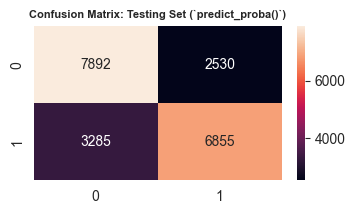

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73     10422
           1       0.73      0.68      0.70     10140

    accuracy                           0.72     20562
   macro avg       0.72      0.72      0.72     20562
weighted avg       0.72      0.72      0.72     20562

Evaluation Performance `predict()` with Direct Predictions
Confusion Matrix:
[[8185 2237]
 [3606 6534]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7158
Precision               0.7450
Recall (Sensitivity)    0.6444
F1-Score                0.6910
Specificity             0.7854
dtype: float64

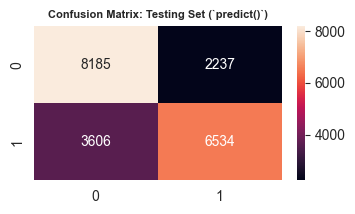

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.79      0.74     10422
           1       0.74      0.64      0.69     10140

    accuracy                           0.72     20562
   macro avg       0.72      0.71      0.71     20562
weighted avg       0.72      0.72      0.71     20562



In [59]:
# Evaluation of performance metrics [Two Methods] between `predict_proba()` and `predict()` [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# `predict_proba()` with 0.5 Threshold (Cutoff) [Support Vector Classifier]
formatting(); print(f"{color.BOLD}Performance `predict_proba()` with 0.5 Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, svm_testing_predictions_0_5))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, svm_testing_predictions_0_5))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, svm_testing_predictions_0_5, labels= [0,1]), fmt=".0f", annot= True)
plt.title("Confusion Matrix: Testing Set (`predict_proba()`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, svm_testing_predictions_0_5))

log_progress ("(6.1.4.2) [Support Vector Classifier] Model Evaluation: `predict_proba()` with 0.5 Threshold (Cutoff)", "INFO")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# `predict()` for direct predictions [Support Vector Classifier]
formatting(); print(f"{color.BOLD}Evaluation Performance `predict()` with Direct Predictions{color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, svm_testing_direct_predictions))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, svm_testing_direct_predictions))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, svm_testing_direct_predictions, labels= [0,1]), fmt=".0f", annot= True)
plt.title("Confusion Matrix: Testing Set (`predict()`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, svm_testing_direct_predictions))

log_progress ("(6.1.4.3) [Support Vector Classifier] Model Evaluation: `predict()` for direct predictions", "INFO")


<span style="font-size:20px; font-weight:bold">6.1.5 Analyse ROC Curve and Determine Optimal Cutoff</span>

Evaluate the model across different classification thresholds using the ROC curve, identify an appropriate cutoff, and assess the trade-off between true positive and false positive rates.

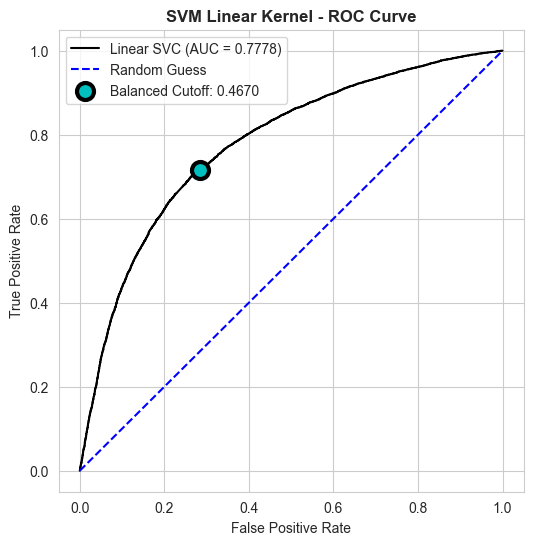

In [60]:
# Plot the ROC curve [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# fpr --> False Positive Rate: False Alarm Rate: How often the model incorrectly predicts a negative case as positive.
# tpr --> True Positive Rate: Sensitivity(Recall): How often the model correctly predicts the positive cases.
# thresholds --> Also known as cutoff.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, svm_probability_test)
roc_auc = roc_auc_score(y_test, svm_probability_test)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Calculating the Balanced Optimal Cutoff directly on the Testing ROC variables [Sensitivity is tpr | Specificity is (1 - fpr)]
specificity_test = 1 - fpr
gap_scores = np.abs(tpr - specificity_test)
balanced_index = np.argmin(gap_scores)
balanced_threshold = thresholds[balanced_index]

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------    
log_progress ("(6.1.5.1) [Support Vector Classifier] SVM Linear Kernel - Visualization of ROC Curve", "INFO")

plt.figure(figsize= (6,6))
plt.plot(fpr, tpr, color= "black", label= f"Linear SVC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color= "blue", label= "Random Guess")
plt.scatter(fpr[balanced_index], tpr[balanced_index], s= 150, color= "c", zorder= 3, label= f"Balanced Cutoff: {balanced_threshold:.4f}", linewidth= 3, edgecolor="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM Linear Kernel - ROC Curve", fontweight="bold")
plt.legend()
plt.show()


<span style="font-size:20px; font-weight:bold">6.1.6 Analyse Performance Across Probability Cutoffs</span>

Evaluate accuracy, sensitivity, and specificity across different probability cutoffs to identify a suitable threshold for classification.

In [61]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def cutoff_table_generator(y_true, probability):
    """
    Docstring:
                Generates performance metrics (Cutoff, Accuracy, Sensitivity, Specificity)
                across a range of probability cuttoffs.
                
    Parameters:
                y_true: Ground Truth Target Values (0,1)
                probability: Probability estimates for positive class [P(cardio) = 1].
                
    Returns:    pd.DataFrame()
                A dataframe containing 21 observations and 4 features.
                Features: ['Cutoff', 'Accuracy', 'Sensitivity', 'Specificity']
    """

    # Derived Metrics - at different cutoffs
    derived_metrics = list()
    
    # Different Probability Cutoffs
    for cutoff in np.arange(0, 1.01, 0.05):
        
        # Predictions for Respective Cutoff
        y_pred = (probability >= cutoff).astype("int64")
        
        # Extracting components from confusion matrix
        true_negative, false_positive, false_negative, true_positive = confusion_matrix(y_true, y_pred, labels= [0,1]).ravel()

        derived_metrics.append({
                                "Cutoff": np.round(cutoff, 2),
                                "Accuracy": np.round(accuracy_score(y_true, y_pred), 4),
                                "Sensitivity": np.round(recall_score(y_true, y_pred), 4),
                                "Specificity": np.round(true_negative / (false_positive + true_negative) if (false_positive + true_negative) > 0 else 0.0, 4)
                               })

    return pd.DataFrame(derived_metrics)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
log_progress("(6.1.6.1) 'cutoff_table_generator': Defined function for evaluation metrics across different probability cutoffs", "DEBUG")
log_progress("(6.1.6.2) [Support Vector Classifier] Threshold Analysis: Generated probability cutoff dataframe for training predictions", "DEBUG")
svm_cutoff_df = cutoff_table_generator(y_train, svm_probability_train)
display(svm_cutoff_df)


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.00,0.4954,1.0000,0.0000
1,0.05,0.4987,0.9996,0.0068
2,0.10,0.5149,0.9947,0.0439
3,0.15,0.5429,0.9844,0.1093
4,0.20,0.5689,0.9677,0.1772
5,0.25,0.6016,0.9447,0.2648
6,0.30,0.6351,0.9105,0.3647
7,0.35,0.6685,0.8709,0.4697
8,0.40,0.6995,0.8098,0.5913
9,0.45,0.7176,0.7405,0.6951


Balanced Threshold (Cutoff): Support Vector Classifier: 0.45


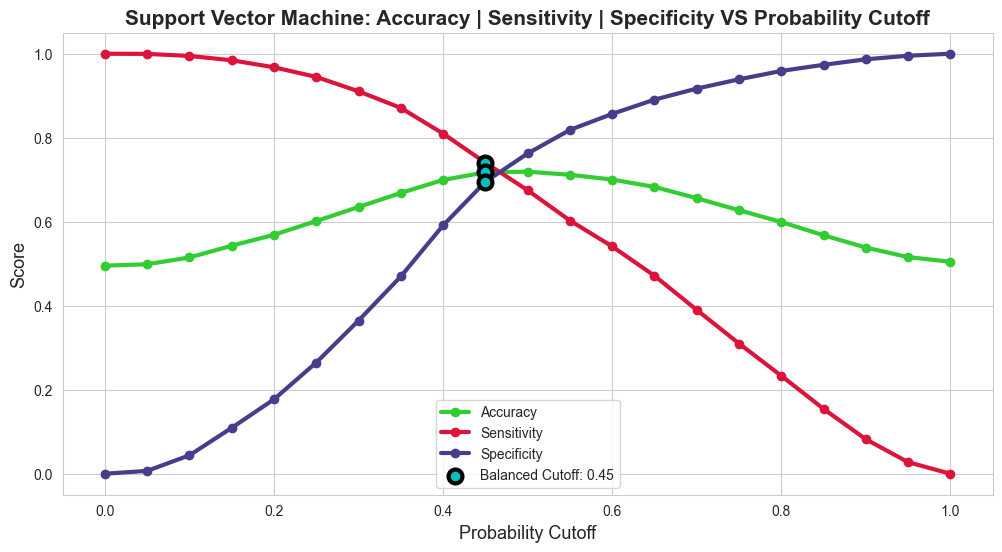

In [62]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Finding Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
svm_cutoff_df["Gap"] = (svm_cutoff_df["Sensitivity"] - svm_cutoff_df["Specificity"]).abs()
balanced_threshold = svm_cutoff_df.loc[svm_cutoff_df["Gap"].idxmin(), "Cutoff"]
balanced_sensitivity = svm_cutoff_df.loc[svm_cutoff_df["Gap"].idxmin(), "Sensitivity"]
balanced_accuracy = svm_cutoff_df.loc[svm_cutoff_df["Gap"].idxmin(), "Accuracy"]
balanced_specificity = svm_cutoff_df.loc[svm_cutoff_df["Gap"].idxmin(), "Specificity"]

log_progress(f"(6.1.6.2) [Support Vector Classifier] Balanced Threshold (Cutoff): {balanced_threshold}", "DEBUG")
print(f"{color.BOLD}Balanced Threshold (Cutoff): Support Vector Classifier:{color.END} {balanced_threshold}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Visualizing Support Vector Classifier: Accuracy/Sensitivity/Specificity vs Probability Cutoff [Support Vector Classifier]
plt.figure(figsize=(12,6))
for feature, colors in zip(("Accuracy", "Sensitivity", "Specificity"),("limegreen", "crimson", "darkslateblue")): 
    plt.plot(svm_cutoff_df["Cutoff"], svm_cutoff_df[feature], label= feature, color= colors, lw= 3, marker= "o")

# Logging: Visualization of Accuracy/Sensitivity/Specificity vs Probability Cutoff
log_progress(f"(6.1.6.3) [Support Vector Classifier] Visualization of Accuracy/Sensitivity/Specificity vs Probability Cutoff", "DEBUG")

# Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
plt.scatter(balanced_threshold, balanced_sensitivity, s= 100, color= "c", zorder= 3, label= f"Balanced Cutoff: {balanced_threshold:.2f}", linewidth= 3, edgecolor="black")
plt.scatter(balanced_threshold, balanced_accuracy, s= 100, color= "c", zorder= 3, linewidth= 3, edgecolor="black")
plt.scatter(balanced_threshold, balanced_specificity, s= 100, color= "c", zorder= 3, linewidth= 3, edgecolor="black")

plt.xlabel("Probability Cutoff", fontsize= 13)
plt.ylabel("Score", fontsize= 13)
plt.title("Support Vector Machine: Accuracy | Sensitivity | Specificity VS Probability Cutoff", fontsize= 15, fontweight="bold")
plt.legend()
plt.show()


To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

<span style="font-size:20px; font-weight:bold">6.1.7 Apply Optimal Cutoff and Evaluate</span>

Assign class labels to the training and test sets using the optimal probability cutoff, then calculate evaluation metrics to assess model performance and identify potential overfitting.


In [63]:
# Making the final prediction based on the clinical optimal cutoff [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# -- Accuracy --> 71.76%
# -- Sensitivity --> 74.05%
# -- Specificity --> 69.51%
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
final_clinical_cutoff = balanced_threshold 
print(f"Clinical Cutoff of {final_clinical_cutoff} is the most suitable threshold for CardioCare's operational and clinical objectives.")

# Final Predictions: Based on Final Clinical Cutoff [Considered the problem at hand]
svm_training_final = (svm_probability_train >= final_clinical_cutoff).astype("int64")
svm_testing_final  = (svm_probability_test >= final_clinical_cutoff).astype("int64")

# Logging: Final Predictions: Based on Final Clinical Cutoff
log_progress(f"(6.1.7.1) [Support Vector Classifier] Applied Balanced Threshold ({final_clinical_cutoff}) for final SVC Classification Predictions.", "DEBUG")


Clinical Cutoff of 0.45 is the most suitable threshold for CardioCare's operational and clinical objectives.


Performance of `Training Dataset` with 0.45 Threshold (Cutoff)
Confusion Matrix:
[[16827  7380]
 [ 6168 17602]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7176
Precision               0.7046
Recall (Sensitivity)    0.7405
F1-Score                0.7221
Specificity             0.6951
dtype: float64

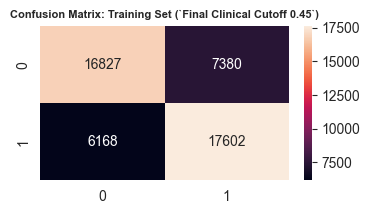

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71     24207
           1       0.70      0.74      0.72     23770

    accuracy                           0.72     47977
   macro avg       0.72      0.72      0.72     47977
weighted avg       0.72      0.72      0.72     47977



In [64]:
# Evaluation of model performance metrics: Training Dataset [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------# `predict()` for direct predictions
# Model Evaluation [Training Dataset] with 0.45 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Training Dataset` with {final_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, svm_training_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, svm_training_final))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, svm_training_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Training Set (`Final Clinical Cutoff {final_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, svm_training_final))

# Logging: SVC Model Evaluation: Training Dataset
log_progress(f"(6.1.7.2) [Support Vector Classifier] Evaluation of model performance metrics: Training Dataset", "DEBUG")


Performance of `Testing Dataset` with 0.45 Threshold (Cutoff)
Confusion Matrix:
[[7176 3246]
 [2657 7483]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7129
Precision               0.6975
Recall (Sensitivity)    0.7380
F1-Score                0.7171
Specificity             0.6885
dtype: float64

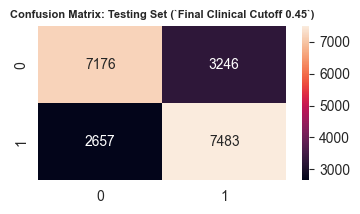

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.69      0.71     10422
           1       0.70      0.74      0.72     10140

    accuracy                           0.71     20562
   macro avg       0.71      0.71      0.71     20562
weighted avg       0.71      0.71      0.71     20562



In [65]:
# Evaluation of model performance metrics: Testing Dataset [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Testing Dataset] with 0.45 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Testing Dataset` with {final_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, svm_testing_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, svm_testing_final))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, svm_testing_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`Final Clinical Cutoff {final_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, svm_testing_final))

# Logging: SVC Model Evaluation: Testing Dataset
log_progress(f"(6.1.7.3) [Support Vector Classifier] Evaluation of model performance metrics: Testing Dataset", "DEBUG")


<span style="font-size:20px; font-weight:bold">6.1.8 Plot the Precision-Recall Curve</span>

Plot the precision-recall curve to evaluate the trade-off between precision and recall.

Support Vector Classifier - Unique probabilities: 20166



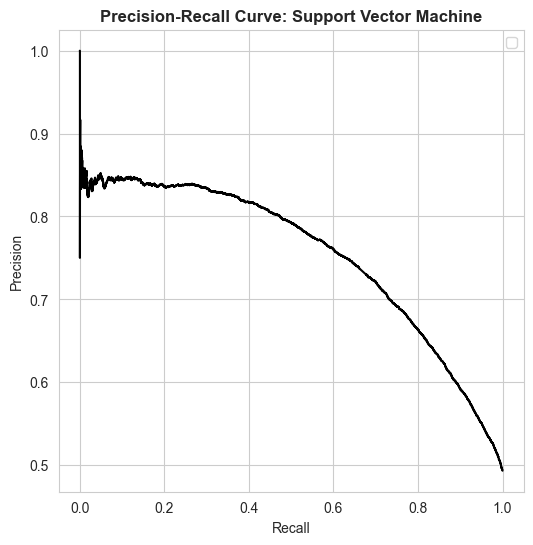

In [66]:
# Compute precision–recall values and plot for various thresholds [Support Vector Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, svm_probability_test)

print("Support Vector Classifier - Unique probabilities:", len(np.unique(svm_probability_test))); print()
log_progress(f"(6.1.8.1) [Support Vector Classifier] Visualization of Precision-Recall Curve", "DEBUG")

plt.figure(figsize= (6,6))
plt.plot(recall, precision, color= "black")
plt.title("Precision-Recall Curve: Support Vector Machine", fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


<span style="font-size:22px; font-weight:bold">6.2 Decision Tree Classifier</span>

<span style="font-size:20px; font-weight:bold">6.2.1 Define and Train the Decision Tree Classifier</span>

Define a Decision Tree Classifier and fit the model on the training data.

In [67]:
# Define and fit [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_classifier_model = DecisionTreeClassifier(random_state=42)
dt_classifier_model.fit(X_train_scaled, y_train)

print(f"{color.BOLD}Decision Tree Classifier Model has been defined:{color.END} [random_state=42]")
print(f"{color.BOLD}Classes:{color.END}", dt_classifier_model.classes_)
log_progress("(6.2.1.1) Decision Tree Classifier Model has been defined: {random_state=42}")


Decision Tree Classifier Model has been defined: [random_state=42]
Classes: [0 1]


<span style="font-size:20px; font-weight:bold">6.2.2 Analyse Feature Importance</span>

Calculate and examine the feature importance scores to identify the variables contributing most to the Decision Tree's predictions.

In [68]:
# Get feature importance scores from the trained model [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
feature_importance_df = pd.DataFrame(dt_classifier_model.feature_importances_, index= X_train_scaled.columns.str.upper(), columns= ["FI Score"])
log_progress("(6.2.2.1) [Decision Tree Classifier] Feature Importance Scores has been extracted from the trained model.")
display(feature_importance_df.round(3))


,FI Score
AGE,0.266
BMI,0.378
MAP,0.249
GENDER,0.031
CHOLESTEROL,0.018
GLUCOSE,0.019
SMOKE,0.011
ALCOHOL,0.009
ACTIVE,0.019


<span style="font-size:20px; font-weight:bold">6.2.3 Generate Probability Estimates and Predictions</span>

Generate probability estimates for the train and test set using `predict_proba()`, apply the default 0.5 threshold to assign class labels, and examine the resulting class distribution.

In [69]:
# Predict the class probabilities [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_probability_train = dt_classifier_model.predict_proba(X_train_scaled)[:, 1]
dt_probability_test  = dt_classifier_model.predict_proba(X_test_scaled)[:, 1]

print(f"{color.BOLD}[Decision Tree Classifier] Training and Testing Probabilities Generated successfully!{color.END}\n")
log_progress("(6.2.3.1) [Decision Tree Classifier] Training and Testing Probabilities Generated successfully!")
print(f"Training Set Probabilities Shape: {dt_probability_train.shape}")
print(f"Testing Set Probabilities Shape: {dt_probability_test.shape}")

print(f"\nTraining Set - First 5 Probabilities: {dt_probability_train[:5]}")
print(f"Testing Set  - First 5 Probabilities: {dt_probability_test[:5]}")


[Decision Tree Classifier] Training and Testing Probabilities Generated successfully!

Training Set Probabilities Shape: (47977,)
Testing Set Probabilities Shape: (20562,)

Training Set - First 5 Probabilities: [0. 1. 1. 0. 1.]
Testing Set  - First 5 Probabilities: [1. 1. 1. 0. 1.]


<span style="font-size:20px; font-weight:bold">6.2.4 Generate Predictions Using the Default Cutoff</span>

Generate predictions on the test data using the default probability cutoff of 0.5

In [70]:
# Make class predictions based on default cutoff value of 0.5 on testing data [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_training_predictions_0_5 = (dt_probability_train >= 0.5).astype("int64")
dt_testing_predictions_0_5  = (dt_probability_test >= 0.5).astype("int64")

print(f"{color.BOLD}[Decision Tree Classifier] Training and Testing Predictions Generated successfully! [Industry Standard Cutoff: 0.5]{color.END}\n")
log_progress("(6.2.4.1) [Decision Tree Classifier] Training and Testing Predictions Generated successfully! [Standard Cutoff: 0.5]")
print(f"Training Set Predictions Shape: {dt_training_predictions_0_5.shape}")
print(f"Testing Set Predictions Shape: {dt_testing_predictions_0_5.shape}")

print(f"\nTraining Set - First 5 Predictions: {dt_training_predictions_0_5[:5]}")
print(f"Testing Set  - First 5 Predictions: {dt_testing_predictions_0_5[:5]}")


[Decision Tree Classifier] Training and Testing Predictions Generated successfully! [Industry Standard Cutoff: 0.5]

Training Set Predictions Shape: (47977,)
Testing Set Predictions Shape: (20562,)

Training Set - First 5 Predictions: [0 1 1 0 1]
Testing Set  - First 5 Predictions: [1 1 1 0 1]


<span style="font-size:20px; font-weight:bold">6.2.5 Evaluate Model Performance</span>

Evaluate the Decision Tree model using appropriate classification metrics to assess its predictive performance.

Performance `predict_proba()` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[24028   179]
 [   17 23753]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.9959
Precision               0.9925
Recall (Sensitivity)    0.9993
F1-Score                0.9959
Specificity             0.9926
dtype: float64

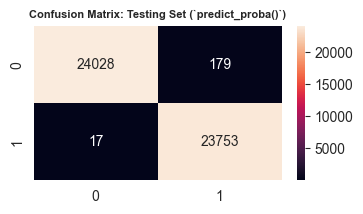

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24207
           1       0.99      1.00      1.00     23770

    accuracy                           1.00     47977
   macro avg       1.00      1.00      1.00     47977
weighted avg       1.00      1.00      1.00     47977



In [71]:
# Evaluation of model performance metrics: Training Dataset [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------# `predict()` for direct predictions
# Model Evaluation [Training Dataset] with 0.50 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance `predict_proba()` with 0.5 Threshold (Cutoff){color.END}"); formatting()
log_progress("(6.2.5.1) [Decision Tree Classifier] Evaluation of Performance `predict_proba()` with 0.5 Threshold (Cutoff)")

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, dt_training_predictions_0_5))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, dt_training_predictions_0_5))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, dt_training_predictions_0_5, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`predict_proba()`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, dt_training_predictions_0_5))


<span style="font-size:20px; font-weight:bold">6.2.6 Analyse ROC Curve and Determine Optimal Cutoff</span>

Evaluate the Decision Tree across different classification thresholds using the ROC curve and identify an appropriate cutoff based on the trade-off between true positive and false positive rates.

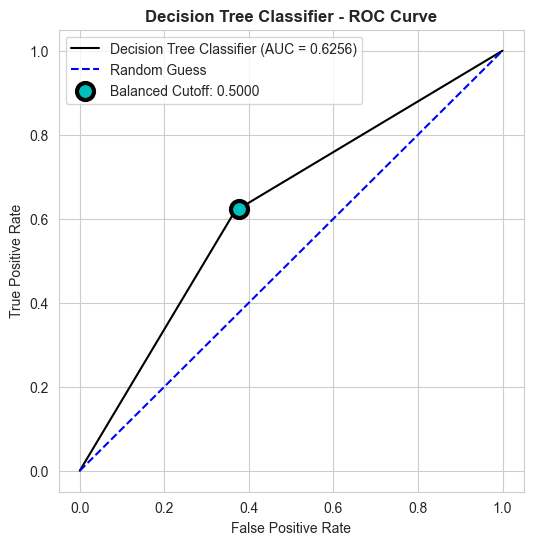

In [72]:
# Plot the ROC curve [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# fpr --> False Positive Rate: False Alarm Rate: How often the model incorrectly predicts a negative case as positive.
# tpr --> True Positive Rate: Sensitivity(Recall): How often the model correctly predicts the positive cases.
# thresholds --> Also known as cutoff.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, dt_probability_test)
roc_auc = roc_auc_score(y_test, dt_probability_test)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Calculating the Balanced Optimal Cutoff directly on the Testing ROC variables [Sensitivity is tpr | Specificity is (1 - fpr)]
specificity_test = 1 - fpr
gap_scores = np.abs(tpr - specificity_test)
balanced_index = np.argmin(gap_scores)
balanced_threshold = thresholds[balanced_index]

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------    
log_progress ("(6.2.6.1) [Decision Tree Classifier] Visualization of ROC Curve", "INFO")

plt.figure(figsize= (6,6))
plt.plot(fpr, tpr, color= "black", label= f"Decision Tree Classifier (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color= "blue", label= "Random Guess")
plt.scatter(fpr[balanced_index], tpr[balanced_index], s= 150, color= "c", zorder= 3, label= f"Balanced Cutoff: {balanced_threshold:.4f}", linewidth= 3, edgecolor="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree Classifier - ROC Curve", fontweight="bold")
plt.legend()
plt.show()


<span style="font-size:20px; font-weight:bold">6.2.7 Analyse Performance Across Probability Cutoffs</span>

Evaluate accuracy, sensitivity, and specificity across different probability cutoffs to identify a suitable threshold for classification.

In [73]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs (Default Tree)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_cutoff_df = cutoff_table_generator(y_train, dt_probability_train)
log_progress("(6.2.7.1) [Decision Tree Classifier] Threshold Analysis: Generated probability cutoff dataframe for training predictions", "DEBUG")
display(dt_cutoff_df)


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.00,0.4954,1.0000,0.0000
1,0.05,0.9955,1.0000,0.9911
2,0.10,0.9955,1.0000,0.9911
3,0.15,0.9955,1.0000,0.9911
4,0.20,0.9955,1.0000,0.9911
5,0.25,0.9955,1.0000,0.9911
6,0.30,0.9956,0.9999,0.9914
7,0.35,0.9959,0.9993,0.9926
8,0.40,0.9959,0.9993,0.9926
9,0.45,0.9959,0.9993,0.9926


Balanced Threshold (Cutoff): Decision Tree Classifier: 0.35


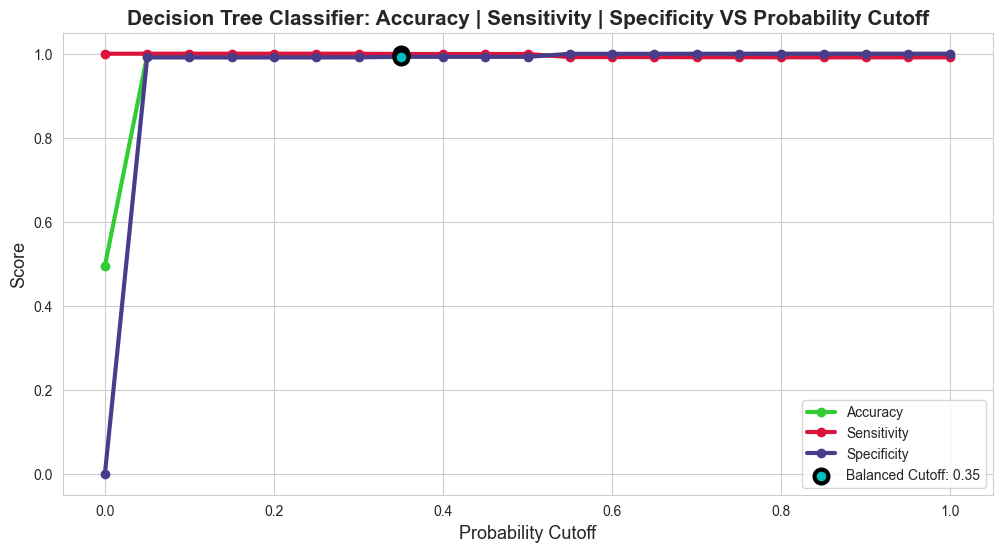

In [74]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Note:
# --> Overfitting - 0.35 Cutoff is the fake peak in training data (The lines are completely flat, because the tree memorized the training data)
# --> Overfit decision tree produces predicted probabilities extremely close to 0 and 1
# --> Because multiple thresholds yielded nearly identical performance, the first maximum (0.35) was selected by the optimisation procedure
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Finding Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_cutoff_df["Gap"] = (dt_cutoff_df["Sensitivity"] - dt_cutoff_df["Specificity"]).abs()
balanced_threshold = dt_cutoff_df.loc[dt_cutoff_df["Gap"].idxmin(), "Cutoff"]
balanced_sensitivity = dt_cutoff_df.loc[dt_cutoff_df["Gap"].idxmin(), "Sensitivity"]
balanced_accuracy = dt_cutoff_df.loc[dt_cutoff_df["Gap"].idxmin(), "Accuracy"]
balanced_specificity = dt_cutoff_df.loc[dt_cutoff_df["Gap"].idxmin(), "Specificity"]

log_progress(f"(6.2.7.2) [Decision Tree Classifier] Balanced Threshold (Cutoff): {balanced_threshold}", "DEBUG")
print(f"{color.BOLD}Balanced Threshold (Cutoff): Decision Tree Classifier:{color.END} {balanced_threshold}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Visualizing Decision Tree Classifier: Accuracy/Sensitivity/Specificity vs Probability Cutoff [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(12,6))
for feature, colors in zip(("Accuracy", "Sensitivity", "Specificity"),("limegreen", "crimson", "darkslateblue")): 
    plt.plot(dt_cutoff_df["Cutoff"], dt_cutoff_df[feature], label= feature, color= colors, lw= 3, marker= "o")

# Logging: Visualization of Accuracy/Sensitivity/Specificity vs Probability Cutoff
log_progress(f"(6.2.7.3) [Decision Tree Classifier] Visualization of Accuracy/Sensitivity/Specificity vs Probability Cutoff", "DEBUG")

# Optimal Threshold: Using Youden's J statistic
plt.scatter(balanced_threshold, balanced_sensitivity, s= 100, color= "c", zorder= 3, label= f"Balanced Cutoff: {balanced_threshold:.2f}", linewidth= 3, edgecolor="black")
plt.scatter(balanced_threshold, balanced_accuracy, s= 100, color= "c", zorder= 3, linewidth= 3, edgecolor="black")
plt.scatter(balanced_threshold, balanced_specificity, s= 100, color= "c", zorder= 3, linewidth= 3, edgecolor="black")

plt.xlabel("Probability Cutoff", fontsize= 13)
plt.ylabel("Score", fontsize= 13)
plt.title("Decision Tree Classifier: Accuracy | Sensitivity | Specificity VS Probability Cutoff", fontsize= 15, fontweight="bold")
plt.legend()
plt.show()


<span style="font-size:20px; font-weight:bold">6.2.8 Apply Optimal Cutoff and Evaluate</span>

Assign class labels to the training and test sets using the optimal probability cutoff, then calculate evaluation metrics to assess model performance and identify potential overfitting.


In [75]:
# Make final prediction based on the optimal cutoff [Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
standard_optimal_cutoff = 0.50 # Raw Decision Tree - Standard Cutoff
print(f"Standard Cutoff of {standard_optimal_cutoff} for a Raw Decision Tree Classifier.")

# Final Predictions: Based on Final Clinical Cutoff [Considered optimal for the problem at hand]
dt_training_final = (dt_probability_train >= standard_optimal_cutoff).astype("int64")
dt_testing_final  = (dt_probability_test >= standard_optimal_cutoff).astype("int64")

# Logging: Final Predictions: Based on Final Clinical Cutoff
log_progress(f"(6.2.8.1) [Decision Tree Classifier] Applied Balanced Threshold ({final_clinical_cutoff}) for final DTC Classification Predictions.", "DEBUG")


Standard Cutoff of 0.5 for a Raw Decision Tree Classifier.


Performance of `Training Dataset` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[24028   179]
 [   17 23753]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.9959
Precision               0.9925
Recall (Sensitivity)    0.9993
F1-Score                0.9959
Specificity             0.9926
dtype: float64

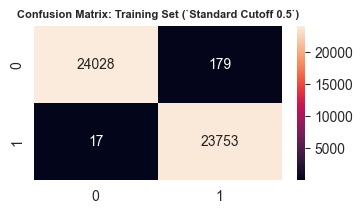

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24207
           1       0.99      1.00      1.00     23770

    accuracy                           1.00     47977
   macro avg       1.00      1.00      1.00     47977
weighted avg       1.00      1.00      1.00     47977

Performance of `Testing Dataset` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[6493 3929]
 [3815 6325]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.6234
Precision               0.6168
Recall (Sensitivity)    0.6238
F1-Score                0.6203
Specificity             0.6230
dtype: float64

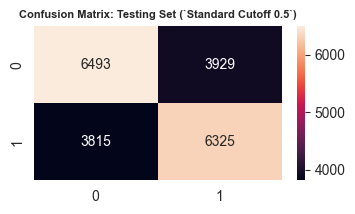

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.62      0.63     10422
           1       0.62      0.62      0.62     10140

    accuracy                           0.62     20562
   macro avg       0.62      0.62      0.62     20562
weighted avg       0.62      0.62      0.62     20562



In [76]:
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Training Dataset [Decision Tree Classifier - Raw]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Training Dataset] with 0.50 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Training Dataset` with {standard_optimal_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, dt_training_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, dt_training_final))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, dt_training_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Training Set (`Standard Cutoff {standard_optimal_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, dt_training_final))

# Logging: DTC Model Evaluation: Training Dataset
log_progress(f"(6.2.8.2) [Decision Tree Classifier] Evaluation of model performance metrics: Training Dataset", "DEBUG")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Testing Dataset [Decision Tree Classifier - Raw]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Testing Dataset] with 0.50 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Testing Dataset` with {standard_optimal_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, dt_testing_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, dt_testing_final))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, dt_testing_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`Standard Cutoff {standard_optimal_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, dt_testing_final))

# Logging: DTC Model Evaluation: Testing Dataset
log_progress(f"(6.2.8.3) [Decision Tree Classifier] Evaluation of model performance metrics: Testing Dataset", "DEBUG")


<span style="font-size:20px; font-weight:bold">6.2.9 Plot the Precision-Recall Curve</span>

Plot the precision-recall curve to evaluate the trade-off between precision and recall.

Decision Tree Classifier - Unique probabilities: 7

Precision= 0.493, Recall= 1.000, Threshold= 0.000
Precision= 0.617, Recall= 0.625, Threshold= 0.250
Precision= 0.617, Recall= 0.624, Threshold= 0.333
Precision= 0.617, Recall= 0.624, Threshold= 0.500
Precision= 0.621, Recall= 0.621, Threshold= 0.667
Precision= 0.621, Recall= 0.621, Threshold= 0.750
Precision= 0.621, Recall= 0.621, Threshold= 1.000


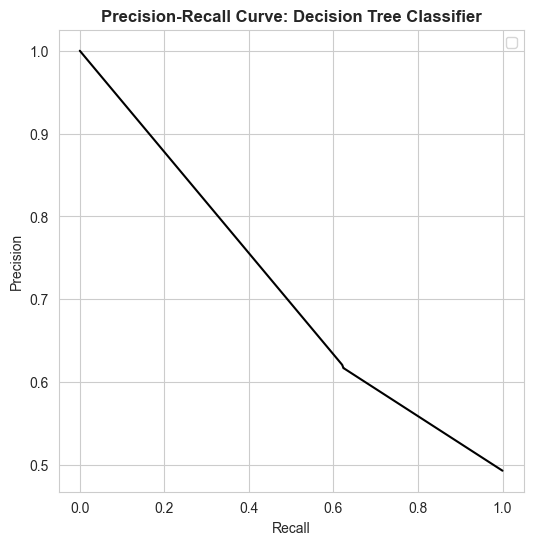

In [77]:
# Compute and plot precision–recall values [Decision Tree Classifier - Raw]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, dt_probability_test)

log_progress(f"(6.2.9.1) [Decision Tree Classifier] Visualization of Precision-Recall Curve", "DEBUG")
print("Decision Tree Classifier - Unique probabilities:", len(np.unique(dt_probability_test))); print()

for prec, rec, thres in zip(precision[:-1], recall[:-1], thresholds):
    print(f"Precision= {prec:.3f}, Recall= {rec:.3f}, Threshold= {thres:.3f}")
    
plt.figure(figsize= (6,6))
plt.plot(recall, precision, color= "black")
plt.title("Precision-Recall Curve: Decision Tree Classifier", fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


<span style="font-size:20px; font-weight:bold">6.2.10 Build a Random Forest Classifier</span>

Build and evaluate a Random Forest Classifier to compare its predictive performance with the other classification models using a consistent evaluation workflow.

In [78]:
# Third model of your choice [Random Forest Classifier - ensemble of many decision trees]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Reasoning: High Variance Mitigation --> Single Decision Tree prone to overfitting, Random Forest is less prone to overfitting.
# Reasoning: Robust to Outliers --> Random Forest are more robust to outliers due to ensemble averaging mechanism.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rf_classifier_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier_model.fit(X_train_scaled, y_train)

print(f"{color.BOLD}Random Forest Classifier Model has been defined:{color.END} [n_estimators=100, random_state=42]")
print(f"{color.BOLD}Classes:{color.END}", rf_classifier_model.classes_)
log_progress("(6.2.10.1) Random Forest Classifier Model has been defined: {n_estimators=100, random_state=42}")


Random Forest Classifier Model has been defined: [n_estimators=100, random_state=42]
Classes: [0 1]


In [79]:
# Predict the class probabilities [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rf_probability_train = rf_classifier_model.predict_proba(X_train_scaled)[:, 1]
rf_probability_test  = rf_classifier_model.predict_proba(X_test_scaled)[:, 1]

print(f"{color.BOLD}[Random Forest Classifier] Training and Testing Probabilities Generated successfully!{color.END}\n")
log_progress("(6.2.10.2) [Random Forest Classifier] Training and Testing Probabilities Generated successfully!")
print(f"Training Set Probabilities Shape: {rf_probability_train.shape}")
print(f"Testing Set Probabilities Shape: {rf_probability_test.shape}")

print(f"\nTraining Set - First 5 Probabilities: {rf_probability_train[:5]}")
print(f"Testing Set  - First 5 Probabilities: {rf_probability_test[:5]}")


[Random Forest Classifier] Training and Testing Probabilities Generated successfully!

Training Set Probabilities Shape: (47977,)
Testing Set Probabilities Shape: (20562,)

Training Set - First 5 Probabilities: [0.11       0.72233333 0.77       0.03       0.98      ]
Testing Set  - First 5 Probabilities: [0.73 0.58 0.51 0.38 0.53]


In [80]:
# Make class predictions based on default cutoff value of 0.5 on testing data [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rf_training_predictions_0_5 = (rf_probability_train >= 0.5).astype("int64")
rf_testing_predictions_0_5  = (rf_probability_test >= 0.5).astype("int64")

print(f"{color.BOLD}[Random Forest Classifier] Training and Testing Predictions Generated successfully! [Industry Standard Cutoff: 0.5]{color.END}\n")
log_progress("(6.2.10.3) [Random Forest Classifier] Training and Testing Predictions Generated successfully! [Standard Cutoff: 0.5]")
print(f"Training Set Predictions Shape: {rf_training_predictions_0_5.shape}")
print(f"Testing Set Predictions Shape: {rf_testing_predictions_0_5.shape}")

print(f"\nTraining Set - First 5 Predictions: {rf_training_predictions_0_5[:5]}")
print(f"Testing Set  - First 5 Predictions: {rf_testing_predictions_0_5[:5]}")


[Random Forest Classifier] Training and Testing Predictions Generated successfully! [Industry Standard Cutoff: 0.5]

Training Set Predictions Shape: (47977,)
Testing Set Predictions Shape: (20562,)

Training Set - First 5 Predictions: [0 1 1 0 1]
Testing Set  - First 5 Predictions: [1 1 1 0 1]


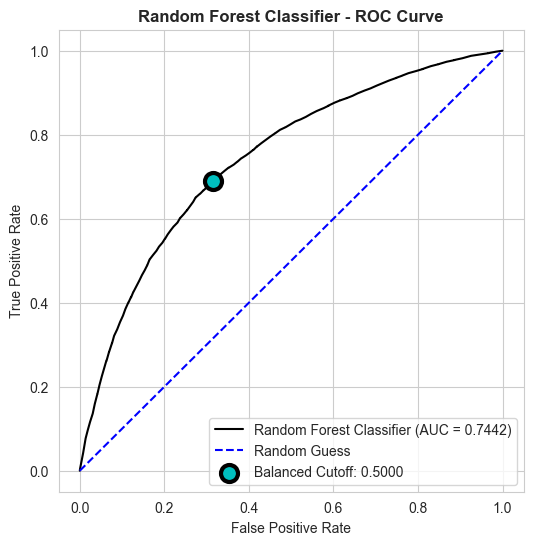

In [81]:
# Plot the ROC curve [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# fpr --> False Positive Rate: False Alarm Rate: How often the model incorrectly predicts a negative case as positive.
# tpr --> True Positive Rate: Sensitivity(Recall): How often the model correctly predicts the positive cases.
# thresholds --> Also known as cutoff.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, rf_probability_test)
roc_auc = roc_auc_score(y_test, rf_probability_test)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Calculating the Balanced Optimal Cutoff directly on the Testing ROC variables [Sensitivity is tpr | Specificity is (1 - fpr)]
specificity_test = 1 - fpr
gap_scores = np.abs(tpr - specificity_test)
balanced_index = np.argmin(gap_scores)
balanced_threshold = thresholds[balanced_index]

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------    
log_progress ("(6.2.10.4) [Random Forest Classifier] Visualization of ROC Curve", "INFO")

plt.figure(figsize= (6,6))
plt.plot(fpr, tpr, color= "black", label= f"Random Forest Classifier (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color= "blue", label= "Random Guess")
plt.scatter(fpr[balanced_index], tpr[balanced_index], s= 150, color= "c", zorder= 3, label= f"Balanced Cutoff: {balanced_threshold:.4f}", linewidth= 3, edgecolor="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest Classifier - ROC Curve", fontweight="bold")
plt.legend()
plt.show()


In [82]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rf_cutoff_df = cutoff_table_generator(y_train, rf_probability_train)
log_progress("(6.2.10.5) [Random Forest Classifier] Threshold Analysis: Generated probability cutoff dataframe for training predictions", "DEBUG")
display(rf_cutoff_df)


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.00,0.4954,1.0000,0.0000
1,0.05,0.6222,1.0000,0.2512
2,0.10,0.7188,1.0000,0.4427
3,0.15,0.8088,1.0000,0.6210
4,0.20,0.8572,1.0000,0.7170
5,0.25,0.9077,0.9999,0.8171
6,0.30,0.9552,0.9998,0.9114
7,0.35,0.9822,0.9995,0.9653
8,0.40,0.9918,0.9992,0.9845
9,0.45,0.9955,0.9976,0.9934


Balanced Threshold (Cutoff): Random Forest Classifier: 0.5


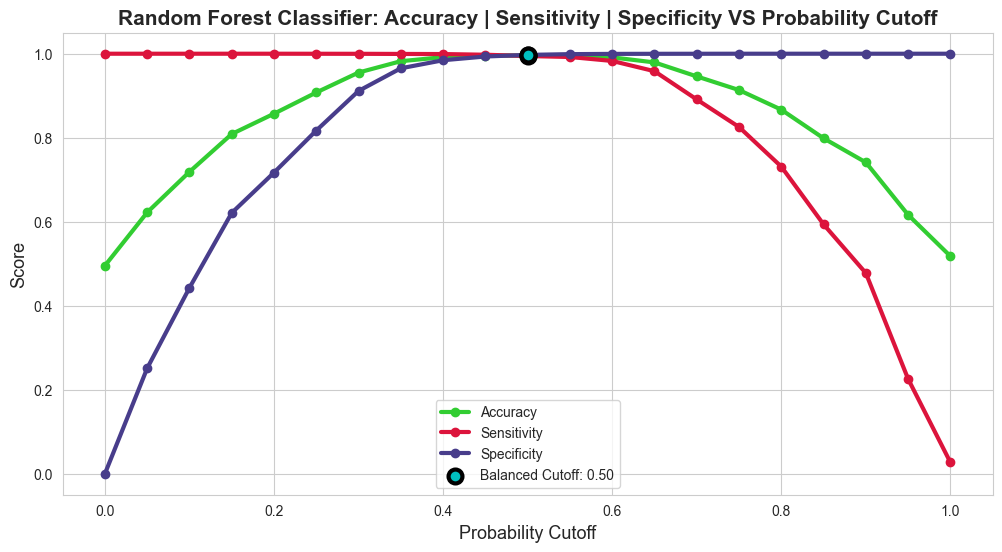

In [83]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Note:
# --> Perfect Memorization: The Random Forest Classifier perfectly memorized the training data (Overfitting)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Finding Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rf_cutoff_df["Gap"] = (rf_cutoff_df["Sensitivity"] - rf_cutoff_df["Specificity"]).abs()
balanced_threshold = rf_cutoff_df.loc[rf_cutoff_df["Gap"].idxmin(), "Cutoff"]
balanced_sensitivity = rf_cutoff_df.loc[rf_cutoff_df["Gap"].idxmin(), "Sensitivity"]
balanced_accuracy = rf_cutoff_df.loc[rf_cutoff_df["Gap"].idxmin(), "Accuracy"]
balanced_specificity = rf_cutoff_df.loc[rf_cutoff_df["Gap"].idxmin(), "Specificity"]

log_progress(f"(6.2.10.6) [Random Forest Classifier] Balanced Threshold (Cutoff): {balanced_threshold}", "DEBUG")
print(f"{color.BOLD}Balanced Threshold (Cutoff): Random Forest Classifier:{color.END} {balanced_threshold}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Visualizing Random Forest Classifier: Accuracy/Sensitivity/Specificity vs Probability Cutoff [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(12,6))
for feature, colors in zip(("Accuracy", "Sensitivity", "Specificity"),("limegreen", "crimson", "darkslateblue")): 
    plt.plot(rf_cutoff_df["Cutoff"], rf_cutoff_df[feature], label= feature, color= colors, lw= 3, marker= "o")

# Logging: Visualization of Accuracy/Sensitivity/Specificity vs Probability Cutoff
log_progress(f"(6.2.10.7) [Random Forest Classifier] Visualization of Accuracy/Sensitivity/Specificity vs Probability Cutoff", "DEBUG")

# Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
plt.scatter(balanced_threshold, balanced_sensitivity, s= 100, color= "c", zorder= 3, label= f"Balanced Cutoff: {balanced_threshold:.2f}", linewidth= 3, edgecolor="black")
plt.scatter(balanced_threshold, balanced_accuracy, s= 100, color= "c", zorder= 3, linewidth= 3, edgecolor="black")
plt.scatter(balanced_threshold, balanced_specificity, s= 100, color= "c", zorder= 3, linewidth= 3, edgecolor="black")

plt.xlabel("Probability Cutoff", fontsize= 13)
plt.ylabel("Score", fontsize= 13)
plt.title("Random Forest Classifier: Accuracy | Sensitivity | Specificity VS Probability Cutoff", fontsize= 15, fontweight="bold")
plt.legend()
plt.show()


In [84]:
# Make final prediction based on the optimal cutoff [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
standard_default_cutoff = 0.50 # Raw Random Forest Classifier - Standard Cutoff
print(f"Standard Cutoff of {standard_default_cutoff} for a Raw Random Forest Classifier.")

# Final Predictions: Based on Final Industry Standard Cutoff [Considered optimal for the problem at hand]
rf_training_final = (rf_probability_train >= standard_default_cutoff).astype("int64")
rf_testing_final  = (rf_probability_test >= standard_default_cutoff).astype("int64")

# Logging: Final Predictions: Based on Final Clinical Cutoff
log_progress(f"(6.2.10.8) [Random Forest Classifier] Applied Balanced Threshold ({final_clinical_cutoff}) for final RFC Classification Predictions.", "DEBUG")


Standard Cutoff of 0.5 for a Raw Random Forest Classifier.


Performance of `Training Dataset` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[24140    67]
 [  131 23639]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.9959
Precision               0.9972
Recall (Sensitivity)    0.9945
F1-Score                0.9958
Specificity             0.9972
dtype: float64

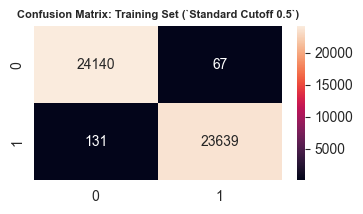

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     24207
           1       1.00      0.99      1.00     23770

    accuracy                           1.00     47977
   macro avg       1.00      1.00      1.00     47977
weighted avg       1.00      1.00      1.00     47977

Performance of `Testing Dataset` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[7140 3282]
 [3147 6993]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.6873
Precision               0.6806
Recall (Sensitivity)    0.6896
F1-Score                0.6851
Specificity             0.6851
dtype: float64

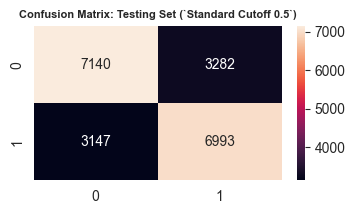

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69     10422
           1       0.68      0.69      0.69     10140

    accuracy                           0.69     20562
   macro avg       0.69      0.69      0.69     20562
weighted avg       0.69      0.69      0.69     20562



In [85]:
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Training Dataset [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Training Dataset] with 0.50 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Training Dataset` with {standard_optimal_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, rf_training_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, rf_training_final))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, rf_training_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Training Set (`Standard Cutoff {standard_optimal_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, rf_training_final))

# Logging: RFC Model Evaluation: Training Dataset
log_progress(f"(6.2.10.9) [Random Forest Classifier] Evaluation of model performance metrics: Training Dataset", "DEBUG")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Testing Dataset [Random Forest Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Testing Dataset] with 0.50 Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Testing Dataset` with {standard_optimal_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, rf_testing_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, rf_testing_final))

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, rf_testing_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`Standard Cutoff {standard_optimal_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, rf_testing_final))

# Logging: RFC Model Evaluation: Testing Dataset
log_progress(f"(6.2.10.10) [Random Forest Classifier] Evaluation of model performance metrics: Testing Dataset", "DEBUG")


<span style="font-size:22px; font-weight:bold">6.3 Hyperparameter Tuning</span>

Optimise the classification models by systematically evaluating hyperparameter combinations using Grid Search to identify the best-performing configurations.

<span style="font-size:20px; font-weight:bold">6.3.1 Grid Search for Optimal Decision Tree Hyperparameters</span>

Use Grid Search to identify the optimal hyperparameter combination for the Decision Tree Classifier and assess whether tuning improves model performance.

In [86]:
# [Decision Tree Classifier] Hyperparameter Tuning - Finding the Best Hyperparameters using 5-Fold Grid Search Cross Validation 
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Use grid search to find best hyperparameters for decision tree model
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_param_grid = {
                 "criterion": ["gini", "entropy"],
                 "max_depth": list(range(2,21,2)),
                 "min_samples_split": [2, 5, 10, 20, 50, 100],
                 "min_samples_leaf": [1, 2, 5, 10, 20, 30, 40, 50]
                }
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Define the parameter grid for the decision tree
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
dt_grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid= dt_param_grid, cv= 5, scoring= "roc_auc", n_jobs=-1, verbose=1)
dt_grid_search.fit(X_train_scaled, y_train)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Print the best hyperparameters
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}Status:{color.END} Decision Tree Classifier 5-Fold Grid Search Cross Validation Completed Successfully.")
log_progress(f"(6.3.1.1) [Fine Tuned DT Classifier] 5-Fold Grid Search Cross Validation Completed Successfully", "INFO")
print(f"{color.BOLD}The Best Hyperparameters for the Decision Tree Classifier:-{color.END}", dt_grid_search.best_params_)
print(f"{color.BOLD}Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination:{color.END}", np.round(dt_grid_search.best_score_, 3))


Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Status: Decision Tree Classifier 5-Fold Grid Search Cross Validation Completed Successfully.
The Best Hyperparameters for the Decision Tree Classifier:- {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50, 'min_samples_split': 2}
Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination: 0.785


<span style="font-size:20px; font-weight:bold">6.3.2 Build the Tuned Decision Tree Model</span>

Build the final Decision Tree Classifier using the optimal hyperparameters identified through Grid Search.

In [87]:
# Use the best DT from grid search
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Trained Decision Tree Classifier with highest Cross Validated ROC-AUC Score
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
best_tuned_dt_model = dt_grid_search.best_estimator_

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Predicting Class Probabilities [Tuned Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tuned_dt_probability_train = best_tuned_dt_model.predict_proba(X_train_scaled)[:, 1]
tuned_dt_probability_test  = best_tuned_dt_model.predict_proba(X_test_scaled)[:, 1]

print(f"{color.BOLD}[Fine Tuned DT Classifier] Training and Testing Probabilities Generated successfully!{color.END}\n")
log_progress(f"(6.3.2.1) [Fine Tuned DT Classifier] Training and Testing Probabilities Generated successfully!", "DEBUG")
print(f"Training Set Probabilities Shape: {tuned_dt_probability_train.shape}")
print(f"Testing Set Probabilities Shape: {tuned_dt_probability_test.shape}")

print(f"\nTraining Set - First 5 Probabilities: {tuned_dt_probability_train[:5]}")
print(f"Testing Set  - First 5 Probabilities: {tuned_dt_probability_test[:5]}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs [Tuned Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tuned_dt_cutoff_df = cutoff_table_generator(y_train, tuned_dt_probability_train)
log_progress("(6.3.2.2) [Fine Tuned DT Classifier] Threshold Analysis: Generated probability cutoff dataframe for training predictions", "DEBUG")
print(f"\n{color.BOLD}Accuracy, Sensitivity, and Specificity at different values of Probability Cutoffs:-{color.END}")
display(tuned_dt_cutoff_df)

# Finding Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
tuned_dt_cutoff_df["Gap"] = (tuned_dt_cutoff_df["Sensitivity"] - tuned_dt_cutoff_df["Specificity"]).abs()
balanced_threshold = tuned_dt_cutoff_df.loc[tuned_dt_cutoff_df["Gap"].idxmin(), "Cutoff"]
log_progress(f"(6.3.2.3) [Fine Tuned DT Classifier] Balanced Threshold (Cutoff): {balanced_threshold}", "DEBUG")
print(f"\n{color.BOLD}Balanced Threshold (Cutoff): Tuned Decision Tree:{color.END} {balanced_threshold}")


[Fine Tuned DT Classifier] Training and Testing Probabilities Generated successfully!

Training Set Probabilities Shape: (47977,)
Testing Set Probabilities Shape: (20562,)

Training Set - First 5 Probabilities: [0.25233451 0.25233451 0.21372855 0.25233451 0.86086957]
Testing Set  - First 5 Probabilities: [0.60280374 0.52256532 0.34786289 0.34786289 0.34786289]

Accuracy, Sensitivity, and Specificity at different values of Probability Cutoffs:-


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.00,0.4954,1.0000,0.0000
1,0.05,0.4954,1.0000,0.0000
2,0.10,0.5132,0.9979,0.0373
3,0.15,0.5522,0.9863,0.1260
4,0.20,0.5813,0.9678,0.2018
5,0.25,0.6140,0.9432,0.2906
6,0.30,0.6668,0.8883,0.4493
7,0.35,0.7180,0.7751,0.6619
8,0.40,0.7202,0.7692,0.6720
9,0.45,0.7230,0.7531,0.6936



Balanced Threshold (Cutoff): Tuned Decision Tree: 0.5


<span style="font-size:20px; font-weight:bold">6.3.3 Evaluate the Tuned Decision Tree Model</span>

Generate predictions using the tuned Decision Tree Classifier and evaluate its performance on the training and test sets to assess generalisation and potential overfitting or underfitting.

In [88]:
# A balanced threshold (Sensitivity ≈ Specificity) is not necessarily an optimal business decision.
# Goal: Identify patients-at-risk along with optimizing doctor's consultation time. --> Best Approach: Balanced Threshold
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# For CardioCare, `IF` identifying patients at risk of having CVD is prioritized over optimizing doctor's consultation time.
# A threshold with higher sensitivity is preferable, because it allows more patient-at-risk to be identified correctly.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
final_dt_clinical_cutoff = balanced_threshold
print(f"Final Clinical Cutoff of {color.BOLD}{final_dt_clinical_cutoff}{color.END} for a Tuned Decision Tree Classifier.")

# Final Predictions: Based on Final Industry Standard Cutoff [Considered optimal for the problem at hand]
tuned_dt_training_final = (tuned_dt_probability_train >= final_dt_clinical_cutoff).astype("int64")
tuned_dt_testing_final  = (tuned_dt_probability_test >= final_dt_clinical_cutoff).astype("int64")

# Logging: Final Predictions: Based on Final Clinical Cutoff
log_progress(f"(6.3.3.1) [Fine Tuned DT Classifier] Applied Balanced Threshold ({final_clinical_cutoff}) for final Classification Predictions.", "DEBUG")


Final Clinical Cutoff of 0.5 for a Tuned Decision Tree Classifier.


Performance of `Training Dataset` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[17737  6470]
 [ 6728 17042]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7249
Precision               0.7248
Recall (Sensitivity)    0.7170
F1-Score                0.7209
Specificity             0.7327
dtype: float64


Tuned Decision Tree ROC AUC Score: 0.7907



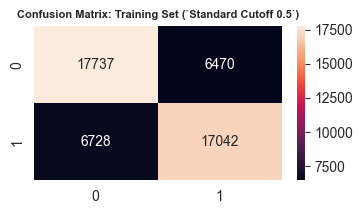

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.73      0.73     24207
           1       0.72      0.72      0.72     23770

    accuracy                           0.72     47977
   macro avg       0.72      0.72      0.72     47977
weighted avg       0.72      0.72      0.72     47977

Performance of `Testing Dataset` with 0.5 Threshold (Cutoff)
Confusion Matrix:
[[7500 2922]
 [2944 7196]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7147
Precision               0.7112
Recall (Sensitivity)    0.7097
F1-Score                0.7104
Specificity             0.7196
dtype: float64


Tuned Decision Tree ROC AUC Score: 0.7803



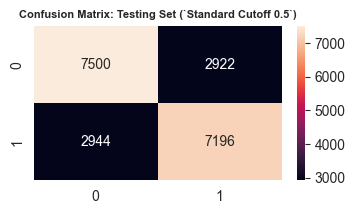

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72     10422
           1       0.71      0.71      0.71     10140

    accuracy                           0.71     20562
   macro avg       0.71      0.71      0.71     20562
weighted avg       0.71      0.71      0.71     20562



In [89]:
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Training Dataset [Tuned Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Training Dataset] with calculated clinical Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Training Dataset` with {final_dt_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, tuned_dt_training_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, tuned_dt_training_final))

print(f"\n{color.BOLD}Tuned Decision Tree ROC AUC Score:{color.END}", round(roc_auc_score(y_train, tuned_dt_probability_train), 4)); print()

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, tuned_dt_training_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Training Set (`Standard Cutoff {final_dt_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, tuned_dt_training_final))

# Logging: Fine Tuned DT Classifier Model Evaluation: Training Dataset
log_progress(f"(6.3.3.2) [Fine Tuned DT Classifier] Evaluation of model performance metrics: Training Dataset", "DEBUG")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Testing Dataset [Tuned Decision Tree Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Testing Dataset] with calculated clinical Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Testing Dataset` with {final_dt_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, tuned_dt_testing_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, tuned_dt_testing_final))

print(f"\n{color.BOLD}Tuned Decision Tree ROC AUC Score:{color.END}", round(roc_auc_score(y_test, tuned_dt_probability_test), 4)); print()

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, tuned_dt_testing_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`Standard Cutoff {final_dt_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, tuned_dt_testing_final))

# Logging: Fine Tuned DT Classifier Model Evaluation: Testing Dataset
log_progress(f"(6.3.3.3) [Fine Tuned DT Classifier] Evaluation of model performance metrics: Testing Dataset", "DEBUG")


<span style="font-size:20px; font-weight:bold">6.3.4 Grid Search for Optimal SVM Hyperparameters</span>

Use Grid Search to identify optimal SVM hyperparameters, including kernel, `C`, and `gamma`, and assess their impact on model performance.

In [90]:
# [Support Vector Classifier] Hyperparameter Tuning - Finding the Best Hyperparameters using 3-Fold Grid Search Cross Validation 
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Use grid search to find best hyperparameters for support vector classifier model
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
svc_param_grid = [{
                  "kernel": ["linear"],
                  "C": [0.1, 1, 10] 
                 },
                 {
                  "kernel": ["rbf"],
                  "C": [0.1, 1, 10], 
                  "gamma": [1, 0.1, "scale", "auto"], 
                 }]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Define the parameter grid for the support vector classifier
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
svc_grid_search = GridSearchCV(SVC(random_state=42, probability=False), svc_param_grid, cv= 3, refit = True, scoring= "roc_auc", verbose = 3, n_jobs= -1) 
svc_grid_search.fit(X_train_scaled, y_train)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Print the best hyperparameters for the support vector classifier
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}Status:{color.END} Support Vector Classifier 3-Fold Grid Search Cross Validation Completed Successfully.")
log_progress(f"(6.3.4.1) [Fine Tuned SVM Classifier] 3-Fold Grid Search Cross Validation Completed Successfully", "INFO")
print(f"{color.BOLD}The Best Hyperparameters for the Support Vector Classifier:-{color.END}", svc_grid_search.best_params_)
print(f"{color.BOLD}Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination:{color.END}", np.round(svc_grid_search.best_score_, 3))


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Status: Support Vector Classifier 3-Fold Grid Search Cross Validation Completed Successfully.
The Best Hyperparameters for the Support Vector Classifier:- {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination: 0.784


Evaluate the SVM classifier with an `RBF kernel` and compare its performance with the `linear SVM model`.

In [91]:
# Use the best SVC from grid search [RBF Kernel]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Tuned Support Vector Classifier with highest Cross Validated ROC-AUC Score
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
best_tuned_svc_params = svc_grid_search.best_params_
best_tuned_svc_model = SVC(**best_tuned_svc_params, random_state=42, probability=True)
best_tuned_svc_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Predicting Class Probabilities [Fine Tuned SVM Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tuned_svc_probability_train = best_tuned_svc_model.predict_proba(X_train_scaled)[:, 1]
tuned_svc_probability_test  = best_tuned_svc_model.predict_proba(X_test_scaled)[:, 1]

print(f"{color.BOLD}[Fine Tuned SVM Classifier] Training and Testing Probabilities Generated successfully!{color.END}\n")
log_progress(f"(6.3.4.2) [Fine Tuned SVM Classifier] Training and Testing Probabilities Generated successfully!", "DEBUG")
print(f"Training Set Probabilities Shape: {tuned_svc_probability_train.shape}")
print(f"Testing Set Probabilities Shape: {tuned_svc_probability_test.shape}")

print(f"\nTraining Set - First 5 Probabilities: {tuned_svc_probability_train[:5]}")
print(f"Testing Set  - First 5 Probabilities: {tuned_svc_probability_test[:5]}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs [Fine Tuned SVM Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tuned_svc_cutoff_df = cutoff_table_generator(y_train, tuned_svc_probability_train)
log_progress("(6.3.4.3) [Fine Tuned SVM Classifier] Threshold Analysis: Generated probability cutoff dataframe for training predictions", "DEBUG")
print(f"\n{color.BOLD}Accuracy, Sensitivity, and Specificity at different values of Probability Cutoffs:-{color.END}")
display(tuned_svc_cutoff_df)

# Finding Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
tuned_svc_cutoff_df["Gap"] = (tuned_svc_cutoff_df["Sensitivity"] - tuned_svc_cutoff_df["Specificity"]).abs()
balanced_threshold = tuned_svc_cutoff_df.loc[tuned_svc_cutoff_df["Gap"].idxmin(), "Cutoff"]
log_progress(f"(6.3.4.4) [Fine Tuned SVM Classifier] Balanced Threshold (Cutoff): {balanced_threshold}", "DEBUG")
print(f"\n{color.BOLD}Balanced Threshold (Cutoff): Tuned SVM Classifier:{color.END} {balanced_threshold}")


[Fine Tuned SVM Classifier] Training and Testing Probabilities Generated successfully!

Training Set Probabilities Shape: (47977,)
Testing Set Probabilities Shape: (20562,)

Training Set - First 5 Probabilities: [0.18514217 0.2489733  0.13783619 0.25113265 0.90393622]
Testing Set  - First 5 Probabilities: [0.53478173 0.65283082 0.37972317 0.25076313 0.37496532]

Accuracy, Sensitivity, and Specificity at different values of Probability Cutoffs:-


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.00,0.4954,1.0000,0.0000
1,0.05,0.4954,1.0000,0.0000
2,0.10,0.4954,1.0000,0.0000
3,0.15,0.5218,0.9869,0.0651
4,0.20,0.5732,0.9585,0.1949
5,0.25,0.5995,0.9386,0.2665
6,0.30,0.6901,0.8499,0.5332
7,0.35,0.7070,0.8141,0.6018
8,0.40,0.7182,0.7687,0.6686
9,0.45,0.7241,0.7316,0.7166



Balanced Threshold (Cutoff): Tuned SVM Classifier: 0.45


In [92]:
# A balanced threshold (Sensitivity ≈ Specificity) is not necessarily an optimal business decision.
# Goal: Identify patients-at-risk along with optimizing doctor's consultation time. --> Best Approach: Balanced Threshold
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# For CardioCare, `IF` identifying patients at risk of having CVD is prioritized over optimizing doctor's consultation time.
# A threshold with higher sensitivity is preferable, because it allows more patient-at-risk to be identified correctly.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
final_svc_clinical_cutoff = balanced_threshold
print(f"Final Clinical Cutoff of {color.BOLD}{final_svc_clinical_cutoff}{color.END} for a Tuned Support Vector Classifier.")

# Final Predictions: Based on Final Industry Standard Cutoff [Considered optimal for the problem at hand]
tuned_svc_training_final = (tuned_svc_probability_train >= final_svc_clinical_cutoff).astype("int64")
tuned_svc_testing_final  = (tuned_svc_probability_test >= final_svc_clinical_cutoff).astype("int64")

# Logging: Final Predictions: Based on Final Clinical Cutoff
log_progress(f"(6.3.4.5) [Fine Tuned SVC Classifier] Applied Balanced Threshold ({final_svc_clinical_cutoff}) for final Classification Predictions.", "DEBUG")


Final Clinical Cutoff of 0.45 for a Tuned Support Vector Classifier.


Performance of `Training Dataset` with 0.45 Threshold (Cutoff)
Confusion Matrix:
[[17347  6860]
 [ 6379 17391]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7241
Precision               0.7171
Recall (Sensitivity)    0.7316
F1-Score                0.7243
Specificity             0.7166
dtype: float64


Tuned Support Vector Classifier ROC AUC Score: 0.7854



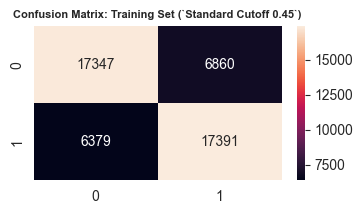

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.72     24207
           1       0.72      0.73      0.72     23770

    accuracy                           0.72     47977
   macro avg       0.72      0.72      0.72     47977
weighted avg       0.72      0.72      0.72     47977

Performance of `Testing Dataset` with 0.45 Threshold (Cutoff)
Confusion Matrix:
[[7412 3010]
 [2737 7403]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7205
Precision               0.7109
Recall (Sensitivity)    0.7301
F1-Score                0.7204
Specificity             0.7112
dtype: float64


Tuned Support Vector Classifier ROC AUC Score: 0.781



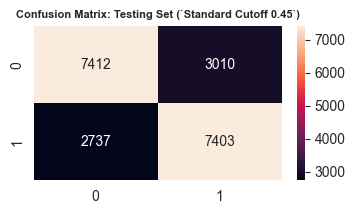

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     10422
           1       0.71      0.73      0.72     10140

    accuracy                           0.72     20562
   macro avg       0.72      0.72      0.72     20562
weighted avg       0.72      0.72      0.72     20562



In [93]:
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Training Dataset [Tuned Support Vector Classifier 3-Fold Grid Search Cross Validation]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Training Dataset] with calculated clinical Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Training Dataset` with {final_svc_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, tuned_svc_training_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, tuned_svc_training_final))

print(f"\n{color.BOLD}Tuned Support Vector Classifier ROC AUC Score:{color.END}", round(roc_auc_score(y_train, tuned_svc_probability_train), 4)); print()

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, tuned_svc_training_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Training Set (`Standard Cutoff {final_svc_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, tuned_svc_training_final))

# Logging: Fine Tuned Support Vector Classifier Model Evaluation: Training Dataset
log_progress(f"(6.3.4.6) [Fine Tuned SVC Classifier] Evaluation of model performance metrics: Training Dataset", "DEBUG")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Testing Dataset [Tuned Support Vector Classifier 3-Fold Grid Search Cross Validation]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Testing Dataset] with calculated clinical Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Testing Dataset` with {final_svc_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, tuned_svc_testing_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, tuned_svc_testing_final))

print(f"\n{color.BOLD}Tuned Support Vector Classifier ROC AUC Score:{color.END}", round(roc_auc_score(y_test, tuned_svc_probability_test), 4)); print()

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, tuned_svc_testing_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`Standard Cutoff {final_svc_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, tuned_svc_testing_final))

# Logging: Fine Tuned Support Vector Classifier Model Evaluation: Testing Dataset
log_progress(f"(6.3.4.7) [Fine Tuned SVC Classifier] Evaluation of model performance metrics: Testing Dataset", "DEBUG")


**Tune the Random Forest Classifier**

Optimise the Random Forest Classifier by tuning its key hyperparameters and evaluating the impact on model performance.

In [94]:
# [Random Forest Classifier] Hyperparameter Tuning - Finding the Best Hyperparameters using 5-Fold Grid Search Cross Validation 
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Use grid search to find best hyperparameters for random forest classifier model
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rfc_param_grid = {
                  "n_estimators": [100, 200],
                  "max_depth": [6, 8, 10, 12], 
                  "min_samples_split": [10, 20, 30],
                  "max_features": ["sqrt"]
                 }
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Define the parameter grid for the Random Forest Classifier
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
rfc_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rfc_param_grid, cv= 5, scoring="roc_auc", n_jobs=-1, verbose= 3)
rfc_grid_search.fit(X_train_scaled, y_train)

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Print the best hyperparameters for the Random Forest Classifier
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(f"{color.BOLD}Status:{color.END} Random Forest Classifier 5-Fold Grid Search Cross Validation Completed Successfully.")
log_progress(f"(6.3.4.8) [Fine Tuned RFC Classifier] 5-Fold Grid Search Cross Validation Completed Successfully", "INFO")
print(f"{color.BOLD}The Best Hyperparameters for the Random Forest Classifier:-{color.END}", rfc_grid_search.best_params_)
print(f"{color.BOLD}Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination:{color.END}", np.round(rfc_grid_search.best_score_, 3))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Status: Random Forest Classifier 5-Fold Grid Search Cross Validation Completed Successfully.
The Best Hyperparameters for the Random Forest Classifier:- {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 20, 'n_estimators': 200}
Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination: 0.791


In [95]:
# Use the best RF from grid search
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Trained Random Forest Classifier with highest Cross Validated ROC-AUC Score
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
best_tuned_rfc_model = rfc_grid_search.best_estimator_

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Predicting Class Probabilities [Fine Tuned RFC Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tuned_rfc_probability_train = best_tuned_rfc_model.predict_proba(X_train_scaled)[:, 1]
tuned_rfc_probability_test  = best_tuned_rfc_model.predict_proba(X_test_scaled)[:, 1]

print(f"{color.BOLD}[Fine Tuned RFC Classifier] Training and Testing Probabilities Generated successfully!{color.END}\n")
log_progress(f"(6.3.4.9) [Fine Tuned RFC Classifier] Training and Testing Probabilities Generated successfully!", "DEBUG")
print(f"Training Set Probabilities Shape: {tuned_rfc_probability_train.shape}")
print(f"Testing Set Probabilities Shape: {tuned_rfc_probability_test.shape}")

print(f"\nTraining Set - First 5 Probabilities: {tuned_rfc_probability_train[:5]}")
print(f"Testing Set  - First 5 Probabilities: {tuned_rfc_probability_test[:5]}")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs [Fine Tuned RFC Classifier]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tuned_rfc_cutoff_df = cutoff_table_generator(y_train, tuned_rfc_probability_train)
log_progress("(6.3.4.10) [Fine Tuned RFC Classifier] Threshold Analysis: Generated probability cutoff dataframe for training predictions", "DEBUG")
print(f"\n{color.BOLD}Accuracy, Sensitivity, and Specificity at different values of Probability Cutoffs:-{color.END}")
display(tuned_rfc_cutoff_df)

# Finding Optimal Threshold: Balanced Optimal Cutoff (Balances Sensitivity and Specificity)
tuned_rfc_cutoff_df["Gap"] = (tuned_rfc_cutoff_df["Sensitivity"] - tuned_rfc_cutoff_df["Specificity"]).abs()
balanced_threshold = tuned_rfc_cutoff_df.loc[tuned_rfc_cutoff_df["Gap"].idxmin(), "Cutoff"]
log_progress(f"(6.3.4.11) [Fine Tuned RFC Classifier] Balanced Threshold (Cutoff): {balanced_threshold}", "DEBUG")
print(f"\n{color.BOLD}Balanced Threshold (Cutoff): Fine Tuned RFC Classifier:{color.END} {balanced_threshold}")


[Fine Tuned RFC Classifier] Training and Testing Probabilities Generated successfully!

Training Set Probabilities Shape: (47977,)
Testing Set Probabilities Shape: (20562,)

Training Set - First 5 Probabilities: [0.20768474 0.25445552 0.17741667 0.23249401 0.83964103]
Testing Set  - First 5 Probabilities: [0.62826773 0.56432115 0.38326253 0.30683731 0.41375436]

Accuracy, Sensitivity, and Specificity at different values of Probability Cutoffs:-


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.00,0.4954,1.0000,0.0000
1,0.05,0.4954,1.0000,0.0000
2,0.10,0.5022,0.9997,0.0138
3,0.15,0.5297,0.9955,0.0724
4,0.20,0.5743,0.9799,0.1760
5,0.25,0.6338,0.9365,0.3365
6,0.30,0.6766,0.8903,0.4666
7,0.35,0.6990,0.8561,0.5448
8,0.40,0.7247,0.7906,0.6599
9,0.45,0.7326,0.7465,0.7190



Balanced Threshold (Cutoff): Fine Tuned RFC Classifier: 0.45


In [96]:
# A balanced threshold (Sensitivity ≈ Specificity) is not necessarily an optimal business decision.
# Goal: Identify patients-at-risk along with optimizing doctor's consultation time. --> Best Approach: Balanced Threshold
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# For CardioCare, `IF` identifying patients at risk of having CVD is prioritized over optimizing doctor's consultation time.
# A threshold with higher sensitivity is preferable, because it allows more patient-at-risk to be identified correctly.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
final_rfc_clinical_cutoff = balanced_threshold
print(f"Final Clinical Cutoff of {color.BOLD}{final_rfc_clinical_cutoff}{color.END} for a Tuned Random Forest Classifier.")

# Final Predictions: Based on Final Industry Standard Cutoff [Considered optimal for the problem at hand]
tuned_rfc_training_final = (tuned_rfc_probability_train >= final_rfc_clinical_cutoff).astype("int64")
tuned_rfc_testing_final  = (tuned_rfc_probability_test >= final_rfc_clinical_cutoff).astype("int64")

# Logging: Final Predictions: Based on Final Clinical Cutoff
log_progress(f"(6.3.4.12) [Fine Tuned RFC Classifier] Applied Balanced Threshold ({final_rfc_clinical_cutoff}) for final Classification Predictions.", "DEBUG")


Final Clinical Cutoff of 0.45 for a Tuned Random Forest Classifier.


Performance of `Training Dataset` with 0.45 Threshold (Cutoff)
Confusion Matrix:
[[17405  6802]
 [ 6025 17745]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7326
Precision               0.7229
Recall (Sensitivity)    0.7465
F1-Score                0.7345
Specificity             0.7190
dtype: float64


Tuned Random Forest Classifier ROC AUC Score: 0.8052



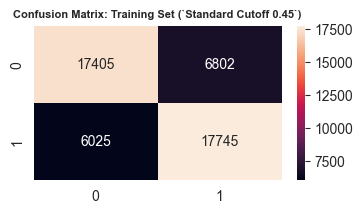

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73     24207
           1       0.72      0.75      0.73     23770

    accuracy                           0.73     47977
   macro avg       0.73      0.73      0.73     47977
weighted avg       0.73      0.73      0.73     47977

Performance of `Testing Dataset` with 0.45 Threshold (Cutoff)
Confusion Matrix:
[[7310 3112]
 [2692 7448]]

Evaluation Metrics Calculated Manually:-


Accuracy                0.7177
Precision               0.7053
Recall (Sensitivity)    0.7345
F1-Score                0.7196
Specificity             0.7014
dtype: float64


Tuned Random Forest Classifier ROC AUC Score: 0.787



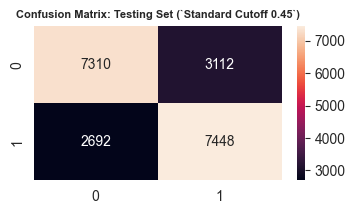

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.72     10422
           1       0.71      0.73      0.72     10140

    accuracy                           0.72     20562
   macro avg       0.72      0.72      0.72     20562
weighted avg       0.72      0.72      0.72     20562



In [97]:
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Training Dataset [Tuned Random Forest Classifier 5-Fold Grid Search Cross Validation]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Training Daataset] with calculated clinical Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Training Dataset` with {final_rfc_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_train, tuned_rfc_training_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_train, tuned_rfc_training_final))

print(f"\n{color.BOLD}Tuned Random Forest Classifier ROC AUC Score:{color.END}", round(roc_auc_score(y_train, tuned_rfc_probability_train), 4)); print()

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_train, tuned_rfc_training_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Training Set (`Standard Cutoff {final_rfc_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_train, tuned_rfc_training_final))

# Logging: Fine Tuned RF Classifier Model Evaluation: Training Dataset
log_progress(f"(6.3.4.13) [Fine Tuned RFC Classifier] Evaluation of model performance metrics: Training Dataset", "DEBUG")

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Evaluation of model performance metrics: Testing Dataset [Tuned Random Forest Classifier 5-Fold Grid Search Cross Validation]
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Model Evaluation [Testing Dataset] with calculated clinical Threshold (Cutoff)
formatting(); print(f"{color.BOLD}Performance of `Testing Dataset` with {final_rfc_clinical_cutoff} Threshold (Cutoff){color.END}"); formatting()

print(f"{color.BOLD}Confusion Matrix:{color.END}")
print(confusion_matrix(y_test, tuned_rfc_testing_final))

print(f"\n{color.BOLD}Evaluation Metrics Calculated Manually:-{color.END}")
display(model_evaluation(y_test, tuned_rfc_testing_final))

print(f"\n{color.BOLD}Tuned Random Forest Classifier ROC AUC Score:{color.END}", round(roc_auc_score(y_test, tuned_rfc_probability_test), 4)); print()

plt.figure(figsize= (4,2))
sns.heatmap(confusion_matrix(y_test, tuned_rfc_testing_final, labels= [0,1]), fmt=".0f", annot= True)
plt.title(f"Confusion Matrix: Testing Set (`Standard Cutoff {final_rfc_clinical_cutoff}`)", fontsize=8, fontweight="bold"); plt.show()

print(f"{color.BOLD}Classification Report:{color.END}")
print(classification_report(y_test, tuned_rfc_testing_final))

# Logging: Fine Tuned RF Classifier Model Evaluation: Testing Dataset
log_progress(f"(6.3.4.14) [Fine Tuned RFC Classifier] Evaluation of model performance metrics: Testing Dataset\n", "DEBUG")


---

<span style="font-size:25px; font-weight:bold">7. Final Model Evaluation and Selection</span>

Evaluate the finalised models on the test data, compare their performance, and summarise the key findings and insights from the modelling process.

In [98]:
log_progress ("============================== Step 7 : Final Model Evaluation and Model Selection ==============================", "INFO") 

<span style="font-size:22px; font-weight:bold">7.1 Evaluate Final Models</span>

Generate predictions using the tuned models and selected features, evaluate their performance on both training and test data, and create model cards to summarise their results.

<span style="font-size:20px; font-weight:bold">7.1.1 Make Final Predictions and Evaluate</span>

Generate predictions using the final model candidates and evaluate their performance to identify the most suitable model.

In [99]:
# Make predictions on test and train sets using all candidate models
# Use the chosen optimal cutoff
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Make predictions on test and train sets using all candidate models, using the chosen optimal cutoffs.

summary_table = pd.DataFrame({
                        "SVM (RBF Kernel - 3-Fold-CV)"   : {
                                            "Final_Threshold"             : final_svc_clinical_cutoff,
                                            "Training_Accuracy"           : accuracy_score(y_train, tuned_svc_training_final),
                                            "Testing_Accuracy"            : accuracy_score(y_test, tuned_svc_testing_final),
                                            "Testing_Sensitivity(Recall)" : recall_score(y_test, tuned_svc_testing_final),
                                            "Testing_Specificity"         : confusion_matrix(y_test, tuned_svc_testing_final)[0,0] / 
                                                                            confusion_matrix(y_test, tuned_svc_testing_final)[0].sum(),
                                            "Testing_AUC_Score"           : roc_auc_score(y_test, tuned_svc_probability_test),
                                            },
                        "Fine-Tuned Decision Tree [5-Fold-CV]": {
                                             "Final_Threshold"             : final_dt_clinical_cutoff,
                                             "Training_Accuracy"           : accuracy_score(y_train, tuned_dt_training_final),
                                             "Testing_Accuracy"            : accuracy_score(y_test, tuned_dt_testing_final),
                                             "Testing_Sensitivity(Recall)" : recall_score(y_test, tuned_dt_testing_final),
                                             "Testing_Specificity"         : confusion_matrix(y_test, tuned_dt_testing_final)[0,0] /
                                                                             confusion_matrix(y_test, tuned_dt_testing_final)[0].sum(),
                                             "Testing_AUC_Score"           : roc_auc_score(y_test, tuned_dt_probability_test),
                                                 },
                        "Fine-Tuned Random Forest [5-Fold-CV]"  : {
                                             "Final_Threshold"             : final_rfc_clinical_cutoff,
                                             "Training_Accuracy"           : accuracy_score(y_train, tuned_rfc_training_final),
                                             "Testing_Accuracy"            : accuracy_score(y_test, tuned_rfc_testing_final),
                                             "Testing_Sensitivity(Recall)" : recall_score(y_test, tuned_rfc_testing_final),
                                             "Testing_Specificity"         : confusion_matrix(y_test, tuned_rfc_testing_final)[0,0] /
                                                                             confusion_matrix(y_test, tuned_rfc_testing_final)[0].sum(),
                                             "Testing_AUC_Score"           : roc_auc_score(y_test, tuned_rfc_probability_test),
                                           }
}).T.round(4)
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
log_progress(f"(7.1.1) [Final Predictions] Final Model Evaluation Summary Table Created\n", "INFO")
print(f"{color.BOLD} [Final Predictions] Final Model Evaluation Summary Table Created:-{color.END}\n")
display(summary_table)


 [Final Predictions] Final Model Evaluation Summary Table Created:-



,Final_Threshold,Training_Accuracy,Testing_Accuracy,Testing_Sensitivity(Recall),Testing_Specificity,Testing_AUC_Score
SVM (RBF Kernel - 3-Fold-CV),0.45,0.7241,0.7205,0.7301,0.7112,0.7810
Fine-Tuned Decision Tree [5-Fold-CV],0.50,0.7249,0.7147,0.7097,0.7196,0.7803
Fine-Tuned Random Forest [5-Fold-CV],0.45,0.7326,0.7177,0.7345,0.7014,0.7870


In [100]:
# Final Logs: Exact End Time and Total Duration of the CardioCare's ML Pipeline
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Logging
log_progress("=========================== Step 8 : CardioCare's ML Pipeline Completion Summary ============================", "INFO")

# Logging the Exact End Time
timeformat = '%Y-%h-%d-%H:%M:%S'
timestamp = datetime.now().strftime(timeformat)

log_progress (f"(8.1) End Time : {timestamp}")

# Logging the Duration (Runtime)

end_time = time.time()
time_duration = end_time - start_time
minutes = time_duration / 60
seconds = time_duration % 60

log_progress (f"(8.2) CardioCare's ML Pipeline Total Duration (Runtime) : {int(minutes)} minutes and {seconds:.0f} seconds")
log_progress ("(8.3) CardioCare's ML Pipeline ---> Completed Successfully.")

print (f"CardioCare's ML Pipeline Total Duration (Runtime) : {int(minutes)} minutes and {seconds:.0f} seconds")
print ("CardioCare's ML Pipeline  ---> Completed Successfully.")


CardioCare's ML Pipeline Total Duration (Runtime) : 53 minutes and 41 seconds
CardioCare's ML Pipeline  ---> Completed Successfully.


<span style="font-size:22px; font-weight:bold">7.2 Conclusion</span>

<span style="font-size:20px; font-weight:bold">7.2.1 Model Cards</span>

Create model cards for all candidate models, summarising their key characteristics, performance, and relevant evaluation results.


**Common Across All Models**

**Data and features:**

* **Summary of raw features:** ['age', 'BMI', 'MAP', 'gender', 'cholesterol', 'glucose', 'smoke', 'alcohol', 'active']
* **Raw Feature Types:** Demographic data, Clinical metrics, Lifestyle data
* **Engineered or transformed features:**
    * **Body Mass Index [BMI]:** Calculated from Raw Height and Weight)
    * **Mean Arterial Pressure [MAP]:** Calculated from Systolic and Diastolic Blood Pressure
* **Preprocessing choices:** Strict outlier removal (Values which were physiologically impossible) were dropped from the dataset.

**Intended use:**

* **Primary task and problem type:** Binary Classification problem, Predict the presence (1) or Absence (0) of CardioVascular Disease.
* **Intended users:** CardioCare (healthcare provider), CardioCare (healthcare staff, doctors, cardiologists)

**Model configuration:**

* **Training details:**
    * **Categorical Variables:** Transformed to numerical representation using Dummy Variables (One-Hot-Encoding) [Type Cast: `int64`]
    * **Numerical Variables:** StandardScaler to ensure they had a mean of zero, and standard deviation of one.

**Limitations and considerations:**

* **Fairness considerations:** Although gender is included as a predictor, the dataset contains a larger proportion of female patients than male patients.

---
---
---

**Model Card: Support Vector Classifier (RBF Kernel - 3-Fold-CV)**

**Model overview:**
A Support Vector Classifier (RBF Kernel) fine tuned via 3-Fold Cross Validation using GridSearch. It is a powerful algorithm used for Binary Classification of patients to determine the presence (1) or Absence (0) of CardioVascular Disease. Its goal is to find the optimal decision boundary called the HyperPlane.

**Intended use:**

* **Suitable deployment or research settings:** Clinical Decision Support System designed to help doctors while evaluating patients.

**Model configuration:**
* **The Best Hyperparameters for the Support Vector Classifier:** {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
* **Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination:** 0.784
* **Final Clinical Cutoff:** 0.45 for a Tuned Support Vector Classifier.
* **Algorithm type:** Support Vector Machine (RBF Kernel) (Supervised Learning)

**Performance:**

* **Training Performance**

| **Metric** | **Training Performance** |
|------------|-------------------------:|
| Accuracy | **72.41%** |
| Precision | **71.71%** |
| Recall (Sensitivity) | **73.16%** |
| Specificity | **71.66%** |
| F1-Score | **72.43%** |
| ROC AUC | **0.7854** |

* **Testing Performance**

| **Metric** | **Testing Performance** |
|------------|------------------------:|
| Accuracy | **72.05%** |
| Precision | **71.09%** |
| Recall (Sensitivity) | **73.01%** |
| Specificity | **71.12%** |
| F1-Score | **72.04%** |
| ROC AUC | **0.781** |

* **Confusion Matrix Key Indicators [Testing Dataset]**
    * **7,412 patients** without cardiovascular disease were **correctly classified** as low risk (True Negatives).
    * **7,403 patients** with cardiovascular disease were **correctly identified** as high risk (True Positives).
    * **3,010 patients** without cardiovascular disease were **incorrectly classified** as high risk (False Positives). Leads to unnecessary consultations.
    * **2,737 patients** with cardiovascular disease were **incorrectly classified** as low risk (False Negatives). Risk of patients not receiving timely treatment.
* **Strengths**
    * Consistent performance across both the training and testing datasets.
    * Produced a balanced sensitivity and specificity, making it suitable for catching patient at-risk while optimizing doctor's consultation time.
    * Achieved a ROC AUC score of 0.781, demonstrating good capability of distinguishing between CVD Presence (1) and CVD Absence (0).
* **Weakness**
    * Model training is computationally expensive, especially for large datasets.
    * The model provides limited interpretability, which is a concern for healthcare professionals.
    * Hyperparameter tuning is computationally intensive due to the need for cross-validation across multiple parameters.

**Limitations and considerations:**

* **Slow Training:** SVC are slow for large datasets.
* **Interpretability constraints:** Considered a "Black Box" model. Due to the complexity of hyperplanes in higher dimensions, SVC are less interpretable.
* **Noise Sensitivity:** They struggle with noisy datasets and overlapping classes.
* **False Positives:** The model incorrectly classified **3,010 healthy patients** as having cardiovascular disease.
* **False Negatives:** The model failed to identify **2,737 patients** who actually had cardiovascular disease.
* **Operational Considerations:** CardioCare's healthcare professionals can use this model for clinical support decision. Model predictions should complement, rather than replace, clinical judgement.
  
---
---
---

**Model Card: Fine-Tuned Decision Tree Classifier [5-Fold-CV]**

**Model overview:**
A Single Decision Tree Classifier fine tuned via 5-Fold Cross Validation using GridSearch. Designed to be an interpretable baseline model.

**Intended use:**

* **Suitable deployment or research settings:** Can be used in environments requiring strict transperency since it is highly interpretable. Serves as a baseline interpretable model for CardioCare's healthcare.

**Model configuration:**
* **The Best Hyperparameters for the Decision Tree Classifier:** {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50, 'min_samples_split': 2}
* **Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination:** 0.785
* **Final Clinical Cutoff:** 0.5 for a Tuned Decision Tree Classifier.
* **Algorithm type:** Decision Tree Classifier (Supervised Learning)

**Performance:**
* **Training Performance**

| **Metric** | **Training Performance** |
|------------|-------------------------:|
| Accuracy | **72.49%** |
| Precision | **72.48%** |
| Recall (Sensitivity) | **71.70%** |
| Specificity | **73.27%** |
| F1-Score | **72.09%** |
| ROC AUC | **0.7907** |

* **Testing Performance**

| **Metric** | **Testing Performance** |
|------------|------------------------:|
| Accuracy | **71.47%** |
| Precision | **71.12%** |
| Recall (Sensitivity) | **70.97%** |
| Specificity | **71.96%** |
| F1-Score | **71.04%** |
| ROC AUC | **0.7803** |

* **Confusion Matrix Key Indicators [Testing Dataset]**
    * **7,500 patients** without cardiovascular disease were **correctly classified** as low risk (True Negatives).
    * **7,196 patients** with cardiovascular disease were **correctly identified** as high risk (True Positives).
    * **2,922 patients** without cardiovascular disease were **incorrectly classified** as high risk (False Positives). Leads to unnecessary consultations.
    * **2,944 patients** with cardiovascular disease were **incorrectly classified** as low risk (False Negatives). Risk of patients not receiving timely treatment.

* **Strengths**
    * Easily understood by healthcare professionals because it produces highly interpretable decision rules.
    * Demonstrates good generalisation, with only a minor performance difference.
    * Requires low computational resources and provides faster prediction for real-time clinical decision support.
* **Weakness**
    * Individual Decision Trees generally provide lower predictive performance than ensemble methods such as Random Forests.
    * Small changes in the training data can produce different tree structures due to high variance.
    * Decision boundaries produced by a single tree may oversimplify complex relationships between characteristics among patients.

**Limitations and considerations:**

* **Overfitting:** Tendency to overfit the training data.
* **High Variance:** Predictions can change with slight variations in the training data.
* **Interpretability constraints:** None, They are highly interpretable. 
* **False Positives:** The model incorrectly classified **2,922 healthy patients** as having cardiovascular disease.
* **False Negatives:** The model failed to identify **2,944 patients** who actually had cardiovascular disease.
* **Operational or domain-specific caveats:** Not recommended for final deployment due to lower rate of capturing at-risk patients (70.97% Recall). Although they offer excellent transperency, they fail to capture a larger proportion of patients with cardiovascular disease.

---
---
---

**Model Card: Fine-Tuned Random Forest Classifier [5-Fold-CV]**

**Model overview:**
An Ensemble Random Forest Classifier fine tuned via 5-Fold Cross Validation using GridSearch. This is the **IDEAL MODEL** for CardioCare, providing the highest predictive power and optimal disease detection rates.

**Intended use:**

* **Suitable deployment or research settings:** Primary Algorithmic Engine for CardioCare's patient-risk assessment pipeline.

**Model configuration:**

* **The Best Hyperparameters for the Random Forest Classifier:** {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 20, 'n_estimators': 200}
* **Best Cross Validated ROC-AUC Score of the best Hyperparameter Combination:** 0.791
* **Final Clinical Cutoff:** 0.45 for a Tuned Random Forest Classifier.
* **Algorithm type:** Random Forest Classifier (Ensemble) (Supervised Learning)

**Performance:**

* **Training Performance**

| **Metric** | **Training Performance** |
|------------|-------------------------:|
| Accuracy | **73.26%** |
| Precision | **72.29%** |
| Recall (Sensitivity) | **74.65%** |
| Specificity | **71.90%** |
| F1-Score | **73.45%** |
| ROC AUC | **0.8052** |

* **Testing Performance**

| **Metric** | **Testing Performance** |
|------------|------------------------:|
| Accuracy | **71.77%** |
| Precision | **70.53%** |
| Recall (Sensitivity) | **73.45%** |
| Specificity | **70.14%** |
| F1-Score | **71.96%** |
| ROC AUC | **0.7870** |

* **Confusion Matrix Key Indicators [Testing Dataset]**
    * **7,310 patients** without cardiovascular disease were **correctly classified** as low risk (True Negatives).
    * **7,448 patients** with cardiovascular disease were **correctly identified** as high risk (True Positives).
    * **3,112 patients** without cardiovascular disease were **incorrectly classified** as high risk (False Positives). Leads to unnecessary consultations.
    * **2,692 patients** with cardiovascular disease were **incorrectly classified** as low risk (False Negatives). Risk of patients not receiving timely treatment.

* **Strengths**
    * Achieved the highest overall predictive performance among the three evaluated machine learning models.
    * Produced the highest sensitivity (`73.45%`), allowing more patients with cardiovascular disease to be correctly identified.
    * Demonstrated good generalisation, consistent training and testing performance.
    * Reduced the risk of overfitting with multiple decision trees (ensemble).
    * Provides feature importance rankings to identify which variables have greater predictive power.
    * Robust to outliers and can handle complex relationships.
* **Weakness**
    * The predictions are less interpretable when compared to a Single Decision Tree.
    * Training time is longer than decision tree.
    * Requires greater compuational resources than simpler models.

**Limitations and considerations:**

* **Interpretability constraints:** Sits in between "Decision Tree" and "Support Vector Machine". Global Feature Importance can be extracted and visualized with ease.
* **False Positives:** The model incorrectly classified **3,112 healthy patients** as having cardiovascular disease.
* **False Negatives:** The model failed to identify **2,692 patients** who actually had cardiovascular disease.
* **Operational or domain-specific caveats:** The fine-tuned Random Forest Classifier is recommended as the preferred deployment model for CardioCare. Its superior predictive performance among the three models, better supports CardioCare's business objective of identifying patients-at-risk along with optimizing doctors valuable consultation time.

---

<span style="font-size:20px; font-weight:bold">7.2.2 Conclusions and Outcomes</span>

**EDA Findings**
- Based on the statistical analysis performed earlier, the dataset was filtered to remove extreme physiological outliers and biologically impossible values.
- Initial Dataset (Number of Observations): 70,000
- Final Dataset (After Dropping Physiologically Impossible Observations): 68,539

**Data Sufficiency**
- The dataset contained approximately 70,000 patient records, which is a sufficient large enough sample for supervised learning models.
- Additional clinical metrics, could further improve the performance of our model's.

**Model Selection (What model did was choosen and Why?)**
- **Decision Tree Classifier**, serving as a highly interpretable baseline model. Not recommended for final deployment due to lower rate of capturing at-risk patients (70.97% Recall). Although they offer excellent transperency, they fail to capture a larger proportion of patients with cardiovascular disease.
- **Support Vector Classifier**, for capturing non-linear relationships capable for modelling more complex decision boundaries. But suffers from high computation cost.
- **Random Forest Classifier**, represents ensemble learning approach which builds multiple decision trees for more accurate and robust predictions. The fine-tuned Random Forest Classifier is recommended as the preferred deployment model for CardioCare. Its superior predictive performance among the three models, better supports CardioCare's business objective of identifying patients-at-risk along with optimizing doctors valuable consultation time.

**Is a Linear Model Sufficient?**
- Unlikely to fully capture the complex relationships between cardiovascular disease risk among patients.
- Superior models like `Random Forest` and `Support Vector Machines (Non-Linear)` are better suited for modelling complex relationships.


---